In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from COMPAS.compas_python_utils.detailed_evolution_plotter import plot_detailed_evolution as det_evo
import tempfile

import h5py as h5 
from astropy import units as u
from astropy import constants as c

import os
import scipy

pd.options.display.max_columns = None

In [3]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
from matplotlib.ticker import LogLocator, AutoMinorLocator, MultipleLocator
# rcParams['font.family'] = 'serif'
# rcParams["mathtext.fontset"] = 'stix'
# rcParams["font.size"] = 18
fontparams = {
    "font.family": "serif",
    "mathtext.fontset" : "stix",
    "grid.color": "gray",
    "grid.linestyle": ":",
    "axes.titlesize": "18",
    "axes.labelsize": "12",
    "xtick.labelsize": "10",
    "ytick.labelsize": "10",
    "xtick.labelbottom": "True",
    "legend.framealpha": "1",
}
rcParams.update(fontparams) 

%config InlineBackend.figure_format='retina' # very useful command for high-res images


In [4]:
from cycler import cycler

colorPalette = {'red': "#E64D4E",
                'orange': "#EE9063",
                'yellow': "#FFDD7B",
                'green': "#77AC54",
                'blue': "#0B92B1",
                'violet': "#665191",
                'gray': "#B4B4B4"
}

custom_cycler = (cycler(color=[colorPalette['red'], colorPalette['blue'], colorPalette['green']]))
color_list = [colorPalette['red'], colorPalette['blue'], colorPalette['green']]

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR','CHE',  '--', '--', 'None']


In [5]:
frac_limit = 1e-4

In [6]:
columns_to_keep = ['Time', 'Mass(1)', 'Mass(2)', 'Radius(1)', 'Radius(2)', 'SemiMajorAxis', 'Eccentricity', 'Stellar_Type(1)', 'Stellar_Type(2)', 'Period(1)', 'Period(2)', 'Period_Orb', 'dmMT(1)', 'dmMT(2)', 'Omega(1)', 'Omega(2)', 'Omega_Orb', 'Record_Type']
columns_to_keep_sanity = ['Time', 'M1', 'M2', 'R1', 'R2', 
                          'M1_conv_env', 'M1_core', 'M2_conv_env', 'M2_core',
                          'R1_conv_env_extent', 'R1_core', 'R2_conv_env_extent', 'R2_core',
                          'SemiMajorAxis_Rsun', 'ecc', 'StellarType_1', 'StellarType_2', 'Period1', 'Period2', 'Period_orb', 'J1_after', 'J2_after', 'Jorb_after', 'dM1_MT', 'dM2_MT', 
                          'ImK22_1', 'ImK22_2', 'ImK22_1_dyn', 'ImK22_2_dyn', 'ImK22_1_eq', 'ImK22_2_eq', 
                          'ImK22_Zahn_Equilibrium1', 'ImK22_Zahn_Equilibrium2', 'ImK22_Zahn_Dynamical1', 'ImK22_Zahn_Dynamical2']


1. INITIAL_STATE
    Record describes the initial state of the binary

2. POST_STELLAR_TIMESTEP
    Record was logged immediately following stellar timestep (i.e. the evolution of the constituent stars for a single timestep)

3.  POST_BINARY_TIMESTEP
    Record was logged immediately following binary timestep (i.e. the evolution of the binary system for a single timestep)

4.  TIMESTEP_COMPLETED
    Record was logged immediately following the completion of the timestep (after all changes to the binary and components)

5.  FINAL_STATE
    Record describes the final state of the binary

6.  STELLAR_TYPE_CHANGE_DURING_CEE
    Record was logged immediately following a stellar type change during a common envelope event

7.  STELLAR_TYPE_CHANGE_DURING_MT
    Record was logged immediately following a stellar type change during a mass transfer event

8.  STELLAR_TYPE_CHANGE_DURING_MASS_RESOLUTION
    Record was logged immediately following a stellar type change during mass resolution

9.  STELLAR_TYPE_CHANGE_DURING_CHE_EQUILIBRATION
    Record was logged immediately following a stellar type change during mass equilibration for CHE

10.  POST_MT
    Record was logged immediately following a mass transfer event

11.  POST_WINDS
    Record was logged immediately following winds mass loss

12.  POST_CEE
    Record was logged immediately following a common envelope event

13.  POST_SN
    Record was logged immediately following a supernova event

14.  POST_MASS_RESOLUTION
    Record was logged immediately following mass resolution (i.e. after winds mass loss & mass transfer complete)

15.  POST_MASS_RESOLUTION_MERGER
    Record was logged immediately following a merger after mass resolution

16.  PRE_STELLAR_TIMESTEP
    Record was logged immediately prior to stellar timestep (i.e. the evolution of the constituent stars for a single timestep)


# SMT BBH that stays narrow / spinning with Tides

In [18]:
notides_DataPath = 'sim_data/smt_notides'
tides_DataPath = 'sim_data/smt_realistic'
perfect_DataPath = 'sim_data/smt_perfect'
# perfect_DataPath = 'sim_data/smt_z77'

# # --------------

df_detailed_notides = pd.read_csv(notides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_notides = df_detailed_notides.rename(columns=lambda x: x.strip())

df_detailed_tides = pd.read_csv(tides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_tides = df_detailed_tides.rename(columns=lambda x: x.strip())

df_detailed_perfect = pd.read_csv(perfect_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_perfect = df_detailed_perfect.rename(columns=lambda x: x.strip())



# df_dco_notides = pd.read_csv(notides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
# df_dco_notides = df_dco_notides.rename(columns=lambda x: x.strip())

# df_dco_tides = pd.read_csv(tides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
# df_dco_tides = df_dco_tides.rename(columns=lambda x: x.strip())

# df_dco_perfect = pd.read_csv(perfect_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
# df_dco_perfect = df_dco_perfect.rename(columns=lambda x: x.strip())


### Realistic Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000046   Zero-age main-sequence, metallicity Z=0.0002   50.231     1     46.182     1     92.920  0.005
  4.587061   Star 1: MS->HG                    48.372     2     44.793     1     96.098  0.005
  4.588658   Stable mass transfer from 1 to 2   18.241     7     74.922     1    193.006  0.000
  4.588658   Star 1: HG->HeMS                  18.241     7     74.922     1    193.006  0.000
  5.036277   Star 1: HeMS->HeHG                18.158     8     74.320     1    196.834  0.000
  5.038021   Star 1 undergoes supernova and forms a BH   18.158    14     74.317     1    196.851  0.000
  6.235508   Star 2: MS->HG                    18.158    14     71.692     2    212.251  0.000
  6.236980   Stable mass transfer from 2 to 1   18.158    14     30.016     7     30.166  0.000
  6.236980   Star 2: HG->HeMS                  18.158    14     30.016     7     30.166  0.000
  6.579525   Star 2: HeMS->

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x16b368e90>])

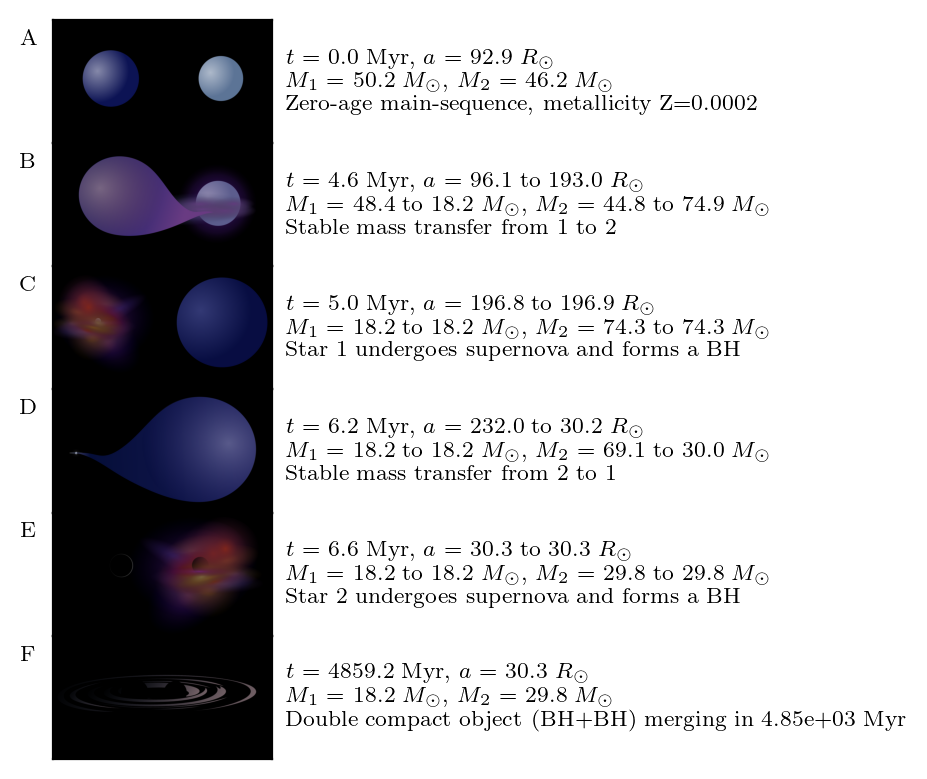

In [62]:
RawData = df_detailed_tides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
# print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [7]:
df_detailed_tides['Period(1)'] = (2 * np.pi / (df_detailed_tides['Omega(1)'].values / u.s)).to(u.day)
df_detailed_tides['Period(2)'] = (2 * np.pi / (df_detailed_tides['Omega(2)'].values / u.s)).to(u.day)

omega_orb = np.sqrt(c.G * (df_detailed_tides['Mass(1)'].values * u.M_sun + df_detailed_tides['Mass(2)'].values * u.M_sun) / (df_detailed_tides['SemiMajorAxis'].values*u.AU)**3).to(1/u.s)
df_detailed_tides['Omega_Orb'] = omega_orb.value
df_detailed_tides['Period_Orb'] = (2 * np.pi / omega_orb).to(u.day)

df_detailed_tides_short = df_detailed_tides[columns_to_keep]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [64]:
# st_change_idx = np.where((df_detailed_tides['Stellar_Type(1)'] != df_detailed_tides['Stellar_Type(1)'].shift()) | (df_detailed_tides['Stellar_Type(2)'] != df_detailed_tides['Stellar_Type(2)'].shift()))[0]
# st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx+1])
# st_changes_with_buffer.sort()
# df_detailed_tides_short.iloc[st_changes_with_buffer] # the +1 is to get the row after the change, which is after tidal effects

In [65]:
# df_dco_tides

In [9]:
df_sanity_tides = pd.read_csv(tides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_tides = df_sanity_tides.rename(columns=lambda x: x.strip())
df_sanity_tides.head()

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn
0,1135,0.000000,0.000056,1,1,374.729,374.729,374.729,374.729,0.000000,0.000037,0.000000,0.000007,261.586,261.586,0.000000,0.012636,0.000000,0.006351,0.350775,0.350774,36.6118,6.10301,0.002949,0.002949,23.6347,4.73158,0.001144,0.001144,0.326353,0.326353,4.833800e-08,1.402600e-08,4.833800e-08,1.402600e-08,3.069270e-07,8.905960e-08,9.049240e-07,2.625780e-07,4.833800e-08,1.402600e-08,4.833800e-08,1.402600e-08,3.069270e-07,8.905960e-08,9.049240e-07,2.625780e-07,0,0,0,0,0,0,0,0,20.7124,3.20676,11.4761,2.22310,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,175845.0,62806.3,8.28917,7.27776,-1.784130e-09,-3.479590e-10,0.000254,0.000127,-2.395400e-09,-4.671740e-10,1.82920,1.46437,0.010313,0.010313,-0.000005,-8.969480e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.880360e-09,9.118570e-10,4.880360e-09,9.118570e-10,3.098840e-08,5.789930e-09,9.136410e-08,1.707070e-08,-1.801320e-10,-2.262140e-11,-2.418480e-10,-3.037180e-11,0.000026,0.000008
1,1135,0.000056,0.014071,1,1,374.722,374.722,374.722,374.714,0.000037,0.006898,0.000007,0.001345,261.574,261.600,0.012634,2.339030,0.006351,1.175770,0.350774,0.350745,36.6106,6.10292,0.002949,0.002949,23.6344,4.73157,0.001144,0.001144,0.326361,0.326339,4.832420e-08,1.402320e-08,4.831170e-08,1.402140e-08,3.068000e-07,8.903580e-08,9.045880e-07,2.625130e-07,4.832420e-08,1.402320e-08,4.831170e-08,1.402140e-08,3.068000e-07,8.903580e-08,9.045880e-07,2.625130e-07,0,0,0,0,0,0,0,0,20.7114,3.20665,11.4759,2.22307,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,175834.0,62805.1,8.28909,7.27773,-1.783130e-09,-3.478110e-10,0.000254,0.000127,-2.394010e-09,-4.669660e-10,1.83027,1.46522,0.010318,0.010318,-0.001189,-2.253050e-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.879240e-09,9.117210e-10,4.877990e-09,9.116030e-10,3.097730e-08,5.788690e-09,9.133520e-08,1.706740e-08,-1.800410e-10,-2.261300e-11,-2.417210e-10,-3.035990e-11,0.000026,0.000008
2,1135,0.014127,0.014064,1,1,374.715,374.715,374.707,374.699,0.006896,0.013769,0.001345,0.002704,261.588,261.614,2.334010,4.659960,1.174110,2.359810,0.350745,0.350715,36.6094,6.10891,0.002955,0.002955,23.6342,4.73478,0.001146,0.001146,0.326346,0.326324,4.743010e-08,1.384730e-08,4.520650e-08,1.351830e-08,2.940500e-07,8.687640e-08,8.739120e-07,2.571690e-07,4.743010e-08,1.384730e-08,4.520650e-08,1.351830e-08,2.940500e-07,8.687640e-08,8.739120e-07,2.571690e-07,0,0,0,0,0,0,0,0,20.6897,3.20120,11.4679,2.22053,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,176058.0,62860.5,8.28766,7.27687,-1.730620e-09,-3.418400e-10,0.000246,0.000125,-2.325550e-09,-4.591760e-10,1.88572,1.50822,0.010655,0.010655,-0.001192,-2.256240e-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.898900e-09,9.143190e-10,4.669230e-09,8.925960e-10,3

In [11]:
df_sanity_tides['SemiMajorAxis_Rsun'] = (df_sanity_tides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_tides['Period1'] = (2 * np.pi / (df_sanity_tides['Omega1'].values / u.yr)).to(u.day)
df_sanity_tides['Period2'] = (2 * np.pi / (df_sanity_tides['Omega2'].values / u.yr)).to(u.day)
df_sanity_tides['Period_orb'] = (2 * np.pi / (df_sanity_tides['Omega'].values / u.yr)).to(u.day)


df_sanity_tides_short = df_sanity_tides[columns_to_keep_sanity]

df_sanity_tides.iloc[np.where(df_sanity_tides['StellarType_2'] == 2)]

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn,SemiMajorAxis_Rsun,Period1,Period2,Period_orb
3037,1135,8.80735,2.297280e-04,14,2,313.502,313.502,286.097,286.097,0.000435,0.000435,27.4041,27.4041,179.987,179.987,1.671660e+09,1.671660e+09,1439.080,1439.080,0.0,0.0,11.8725,0.00005,2.602600e-13,2.602600e-13,45.1741,17.4692,0.019043,0.019043,0.411184,0.411184,0.0,3.081180e-14,0.0,-4.209770e-11,0.0,-3.501920e-11,0.0,-2.873570e-11,0.0,3.081180e-14,0.0,-4.209770e-11,0.0,-3.501920e-11,0.0,-2.873570e-11,0,0,0,0,0,0,0,0,11.8725,0.00005,16.5052,1.27324,0.0,0.0,2.494860e-276,24.5118,0.0,5.167050e-138,0,0.000000e+00,1.000000e-10,675998.0,0.445704,6.86041,-0.0,6.152120e-13,0.0,-1.123930e-08,-0.0,0.0,6683.61,inf,160.140,160.140,0.0,-2.763110e-04,0.0,0.0,0.0,inf,0.0,-inf,0.0,-inf,0.0,-inf,1.527660e-30,-1.659150e-07,-3.697060e-11,-0.000227,-3.697060e-11,-0.000189,-3.697060e-11,-1.547360e-04,1.868270e-39,inf,0.0,NaN,-2.497360e-24,-inf,88.417782,0.000001,1.594723,12.750551
3038,1135,8.80758,2.066580e-06,14,2,313.502,313.502,286.097,286.097,0.000435,0.000435,27.4041,27.4041,179.987,179.987,1.671660e+09,1.671660e+09,1167.610,1167.610,0.0,0.0,11.8725,0.00005,2.602600e-13,2.602600e-13,45.1741,19.4111,0.023470,0.023470,0.411184,0.411184,0.0,1.826540e-14,0.0,-1.370810e-11,0.0,-1.086380e-11,0.0,-8.420370e-12,0.0,1.826540e-14,0.0,-1.370810e-11,0.0,-1.086380e-11,0.0,-8.420370e-12,0,0,0,0,0,0,0,0,11.8725,0.00005,16.5217,1.27401,0.0,0.0,4.866220e-261,24.5118,0.0,2.555510e-130,0,0.000000e+00,1.000000e-10,681452.0,0.445704,6.52129,-0.0,3.232880e-13,0.0,-4.792040e-09,-0.0,0.0,12718.80,inf,375.595,375.595,0.0,-2.373400e-06,0.0,0.0,0.0,inf,0.0,-inf,0.0,-inf,0.0,-inf,1.527660e-30,-2.529280e-07,-3.697060e-11,-0.000190,-3.697060e-11,-0.000150,-3.697060e-11,-1.166000e-04,1.868270e-39,inf,0.0,NaN,-2.497350e-24,-inf,88.417782,0.000001,1.965497,12.750551
3039,1135,8.80758,2.178390e-06,14,2,313.502,313.502,286.097,286.097,0.000435,0.000435,27.4041,27.4041,179.987,179.987,1.671660e+09,1.671660e+09,1165.420,1165.420,0.0,0.0,11.8725,0.00005,2.602600e-13,2.602600e-13,45.1741,19.4296,0.023514,0.023514,0.411184,0.411184,0.0,1.817970e-14,0.0,-1.356970e-11,0.0,-1.074880e-11,0.0,-8.326310e-12,0.0,1.817970e-14,0.0,-1.356970e-11,0.0,-1.074880e-11,0.0,-8.326310e-12,0,0,0,0,0,0,0,0,11.8725,0.00005,16.5218,1.27402,0.0,0.0,6.625950e-261,24.5118,0.0,2.985010e-130,0,0.000000e+00,1.000000e-10,681501.0,0.445704,6.51831,-0.0,3.213870e-13,0.0,-4.754900e-09,-0.0,0.0,12794.10,inf,378.529,378.529,0.0,-2.500500e-06,0.0,0.0,0.0,inf,0.0,-inf,0.0,-inf,0.0,-inf,1.527660e-30,-2.538890e-07,-3.697060e-11,-0.000190,-3.697060e-11,-0.000150,-3.697060e-11,-1.162810e-04,1.868270e-39,inf,0.0,NaN,-2.497350e-24,-inf,88.417

In [10]:
st_change_idx = np.where((df_sanity_tides_short['StellarType_1'] != df_sanity_tides_short['StellarType_1'].shift()) | (df_sanity_tides_short['StellarType_2'] != df_sanity_tides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_tides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,36.6118,23.6347,6.10301,4.73158,0.000000e+00,20.71240,0.000000e+00,11.47610,0.000000e+00,3.206760,0.000000e+00,2.223100,70.176389,3.507740e-01,1,1,181622.975652,3.613465e+05,8.773151,0.000037,0.000007,374.7290,0.000000,0.0000,3.069270e-07,8.905960e-08,3.069270e-07,8.905960e-08,0,0,0.0,0.000000e+00,3.098840e-08,5.789930e-09
1379,5.65109,35.4554,23.4764,15.22220,7.15803,0.000000e+00,11.90050,0.000000e+00,8.26563,0.000000e+00,1.042430,0.000000e+00,1.205570,71.475183,3.489320e-01,1,1,132.877855,5.164175e+01,9.117842,0.306864,0.115606,368.0890,0.000000,0.0000,2.014320e-13,3.795440e-11,2.014320e-13,3.795440e-11,0,0,0.0,0.000000e+00,8.530470e-07,1.613670e-08
1380,5.65109,35.4552,23.4764,14.88250,7.15803,2.492500e-260,11.90050,0.000000e+00,8.26562,4.917450e-130,1.042430,0.000000e+00,1.205570,71.475398,3.489320e-01,2,1,84.825057,5.164186e+01,9.117914,0.306848,0.115606,368.0880,0.000000,0.0000,2.012570e-13,3.795350e-11,2.012570e-13,3.795350e-11,0,0,inf,0.000000e+00,6.956400e-07,1.613640e-08
1563,5.65216,35.4549,23.4764,19.31470,7.15903,2.560210e-226,11.93940,0.000000e+00,8.26502,6.579140e-113,1.044520,0.000000e+00,1.205380,71.475828,3.489320e-01,2,1,142.353234,5.165663e+01,9.118023,0.306816,0.115605,368.0870,0.000000,0.0000,6.289790e-14,3.788080e-11,6.289790e-14,3.788080e-11,0,0,inf,0.000000e+00,2.240020e-06,1.614730e-08
1564,5.65216,11.9395,46.9918,1.04452,8.18978,0.000000e+00,11.93950,0.000000e+00,25.05290,0.000000e+00,1.044520,0.000000e+00,3.027620,78.546301,0.000000e+00,7,1,142.478732,3.960346e-01,10.503945,0.000454,39.499900,277.5390,-23.515400,23.5154,0.000000e+00,-1.139790e-04,0.000000e+00,-1.139790e-04,0,0,0.0,0.000000e+00,2.479020e-12,-5.113550e-04
1752,6.22752,11.8757,46.7997,1.04110,8.85768,0.000000e+00,8.34851,0.000000e+00,23.51670,0.000000e+00,0.000071,0.000000e+00,2.703920,80.808224,0.000000e+00,7,1,145.858233,5.040940e-01,10.984747,0.000438,36.152100,279.4670,0.000000,0.0000,0.000000e+00,-1.555830e-05,0.000000e+00,-1.555830e-05,0,0,0.0,0.000000e+00,2.144120e-12,-3.572120e-04
1753,6.22752,11.8755,46.7989,1.04110,8.85760,0.000000e+00,8.34851,0.000000e+00,23.51620,0.000000e+00,0.000071,0.000000e+00,2.703890,80.817900,0.000000e+00,8,1,43.339964,5.042779e-01,10.986851,0.000438,36.137800,279.4760,0.000000,0.0000,0.000000e+00,-1.555470e-05,0.000000e+00,-1.555470e-05,0,0,0.0,0.000000e+00,1.211370e-12,-3.571250e-04
1828,6.24693,11.8725,46.7924,1.12914,8.88425,0.000000e+00,8.82660,0.000000e+00,23.46460,0.000000e+00,0.000071,0.000000e+00,2.693010,80.904558,0.000000e+00,8,1,44.297748,5.090339e-01,11.005397,0.000435,36.010900,279.5390,0.000000,0.0000,0.000000e+00,-1.442900e-05,0.000000e+00,-1.442900e-05,0,0,0.0,0.000000e+00,1.697690e-12,-3.518270e-04
1829,6.24713,11.8725,46.7923,0.00005,8.88452,0.000000e+00,11.87250,0.000000e+00,23.46410,0.000000e+00,0.000050,0.000000e+00,2.692900,80.905419,0.000000e+00,14,1,0.000001,5.090836e-01,11.005608,0.000435,36.009500,279.5400,0.000000,0.0000,0.000000e+00,-1.441810e-05,0.000000e+00,-1.441810e-05,0,0,0.0,0.000000e+00,-3.697060e-11,-3.517740e-04
3036,8.80735,11.8725,45.1744,0.00005,17.94910,0.000000e+00,11.87250,0.000000e+00,16.50520,0.000000e+00,0.000050,0.000000e+00,1.273240,88.416277,0.000000e+00,14,1,0.000001,2.635707e+00,12.750197,0.000435,27.405900,286.0960,0.000000,0.0000,0.000000e+00,-6.167500e-12,0.000000e+00,-6.167500e-12,0,0,0.0,0.000000e+00,-3.697060e-11,-4.238430e-05


#### Breakdown by tidal mechanism

In [120]:
# Load full data for tidal breakdown
rc = df_sanity_tides["R1_core"].values * u.R_sun              # Rsol
R = df_sanity_tides["R1"].values * u.R_sun                    # Rsol
Renv = df_sanity_tides["R1_conv_env_extent"].values * u.R_sun # Rsol
Rint = R - Renv

rc2 = df_sanity_tides["R2_core"].values * u.R_sun              # Rsol
R2 = df_sanity_tides["R2"].values * u.R_sun                    # Rsol
Renv2 = df_sanity_tides["R2_conv_env_extent"].values * u.R_sun # Rsol
Rint2 = R2 - Renv2

L = df_sanity_tides["Lum_1"].values * u.L_sun                 # Lsol
L2 = df_sanity_tides["Lum_2"].values * u.L_sun                 # Lsol

M = df_sanity_tides["M1"].values * u.M_sun                    # Msol
Mc = df_sanity_tides["M1_core"].values * u.M_sun              # Msol
Menv = df_sanity_tides["M1_conv_env"].values * u.M_sun        # Msol

M2 = df_sanity_tides["M2"].values * u.M_sun                   # Msol
Mc2 = df_sanity_tides["M2_core"].values * u.M_sun              # Msol
Menv2 = df_sanity_tides["M2_conv_env"].values * u.M_sun        # Msol


I1 = df_sanity_tides["I1_before"].values * u.M_sun * u.AU**2  # Msol * AU^2

tau_conv = df_sanity_tides["tau_conv1"].values * u.yr                # yr
tau_conv2 = df_sanity_tides["tau_conv2"].values * u.yr                # yr


omega_orb = df_sanity_tides["Omega_before"].values / u.yr     # 1/yr
omega_spin = df_sanity_tides["Omega1_before"].values / u.yr   # 1/yr
omega_spin2 = df_sanity_tides["Omega2_before"].values / u.yr   # 1/yr

sma = df_sanity_tides["SemiMajorAxis_before"].values * u.AU   # AU
ecc = df_sanity_tides["ecc_before"].values                           # 1
period_orb = 2 * np.pi / df_sanity_tides["Omega_before"].values * u.yr.to(u.day) * u.day     # days

Imk10 = df_sanity_tides["ImK10_1"].values
Imk12 = df_sanity_tides["ImK12_1"].values
Imk22 = df_sanity_tides["ImK22_1"].values
Imk32 = df_sanity_tides["ImK32_1"].values

Imk10_dyn = df_sanity_tides["ImK10_1_dyn"].values
Imk12_dyn = df_sanity_tides["ImK12_1_dyn"].values
Imk22_dyn = df_sanity_tides["ImK22_1_dyn"].values
Imk32_dyn = df_sanity_tides["ImK32_1_dyn"].values

Imk10_eq = df_sanity_tides["ImK10_1_eq"].values
Imk12_eq = df_sanity_tides["ImK12_1_eq"].values
Imk22_eq = df_sanity_tides["ImK22_1_eq"].values
Imk32_eq = df_sanity_tides["ImK32_1_eq"].values

Imk10_2 = df_sanity_tides["ImK10_2"].values
Imk12_2 = df_sanity_tides["ImK12_2"].values
Imk22_2 = df_sanity_tides["ImK22_2"].values
Imk32_2 = df_sanity_tides["ImK32_2"].values

Imk10_2_dyn = df_sanity_tides["ImK10_2_dyn"].values
Imk12_2_dyn = df_sanity_tides["ImK12_2_dyn"].values
Imk22_2_dyn = df_sanity_tides["ImK22_2_dyn"].values
Imk32_2_dyn = df_sanity_tides["ImK32_2_dyn"].values

Imk10_2_eq = df_sanity_tides["ImK10_2_eq"].values
Imk12_2_eq = df_sanity_tides["ImK12_2_eq"].values
Imk22_2_eq = df_sanity_tides["ImK22_2_eq"].values
Imk32_2_eq = df_sanity_tides["ImK32_2_eq"].values

dadt = df_sanity_tides["dadt1"].values * u.AU / u.yr
dOmegadt = df_sanity_tides["dOmegadt1"].values / u.yr**2
dedt1 = df_sanity_tides["dedt1"].values / u.yr


G_AU_Msol_yr = c.G.to(u.AU**3 / u.M_sun / u.yr**2)
Time = df_sanity_tides["Time"].values * 1e6 * u.yr          # yr
st1 = df_sanity_tides["StellarType_1"].values
st2 = df_sanity_tides["StellarType_2"].values

rc_AU = df_sanity_tides["R1_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU = df_sanity_tides["R1_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU = df_sanity_tides["R1"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU = R_AU - Renv_AU                  
Mint = M - Mc - Menv     


rc_AU2 = df_sanity_tides["R2_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU2 = df_sanity_tides["R2_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU2 = df_sanity_tides["R2"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU2 = R_AU2 - Renv_AU2                 
Mint2 = M2 - Mc2 - Menv2    

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR', 'CHE', '--', '--', 'None']

In [121]:
print("Equilibrium tides from turbulent viscosity:")
Imk22_eq[st_changes_with_buffer][1:]

Equilibrium tides from turbulent viscosity:


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [122]:
print("IGW dissipation from convective core -- radiative envelope boundary:")
E2_kushnir = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.)
l=2
m=2
imk22_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk22_core_gw[(rc_AU/R_AU < frac_limit) | (Mc/M < frac_limit) | (Menv/M > frac_limit) | (Renv/R_AU > frac_limit)] = 0.0
imk22_core_gw[np.isnan(imk22_core_gw)] = 0.0
imk22_core_gw[st_changes_with_buffer][1:]


IGW dissipation from convective core -- radiative envelope boundary:


/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [4.70876591e-07, 3.62451199e-11, 5.50725290e-11, 1.06268809e-11,
           7.75363294e-07, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00]>

In [123]:
print("IGW dissipation from radiative zone -- convective shell boundary:")

dNlnr_cbrt = (G_AU_Msol_yr * Mint / (Rint_AU**2 * (R_AU - Rint_AU)))**(1/3)

alpha = Rint_AU/R_AU
beta = Mint/M

# one_minus_beta = 1-beta
one_minus_beta = Menv/M

# gamma = alpha**3 * (1-beta) / (beta * (1 - alpha**3))
rho_conv = Menv / (4 * np.pi * (R_AU**3 - Rint_AU**3))
rho_rad = Mint / (4 * np.pi * (Rint_AU**3 - rc_AU**3))
gamma = rho_conv / rho_rad

Epsilon = alpha**11 * (one_minus_beta) * (1-gamma)**2 * (2*alpha/3 - 1)**2 / (beta**2 * (1-alpha**3) * (1-alpha)**2)


l=2
m=2
imk22_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) * (2*(2+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk22_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk22_env_gw)
imk22_env_gw[(Renv_AU/R_AU < frac_limit) | (Menv/M < frac_limit)] = 0.0
imk22_env_gw[np.isnan(imk22_env_gw)] = 0.0

imk22_env_gw[st_changes_with_buffer][1:]

IGW dissipation from radiative zone -- convective shell boundary:


/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]>

In [124]:
print("Dynamical tides from inertial wave dissipation:")
alpha = Rint_AU/R_AU
beta = Mint/M
one_minus_beta = Menv/M

rho_conv = Menv / ((R_AU**3 - Rint_AU**3))
rho_rad = Mint / ((Rint_AU**3 - rc_AU**3))
gamma = rho_conv / rho_rad

eps = omega_spin / np.sqrt(G_AU_Msol_yr * M / R_AU**3)

b1 = (1 + 2*alpha + 3*alpha**2 + (3/2)*alpha**3)
b2 = 1 + ((1-gamma) / gamma) * alpha**3
b3 = 1 + (3*gamma/2) + ((5*alpha**3)/(2*gamma))*(1 + gamma/2 - (3*gamma**2)/2) - (9/4)*(1-gamma)*alpha**5
imk22_inertial = (100 * np.pi / 63) * eps**2 * (alpha**5 / (1 - alpha**5)) * (1-gamma)**2 * (1-alpha)**4 * b1**2 * b2 * b3**(-2)

imk22_inertial[((Renv_AU/R_AU < frac_limit) & (Menv/M < frac_limit)) | (omega_orb > 2*omega_spin) | (Mint/M < frac_limit)] = 0.0
imk22_inertial = np.sign(omega_orb - omega_spin) * np.abs(imk22_inertial)
imk22_inertial[np.isnan(imk22_inertial)] = 0.0

imk22_inertial[st_changes_with_buffer][1:]

Dynamical tides from inertial wave dissipation:


/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in subtract
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0., -0., -0., -0., -0.,
           -0., -0.]>

### No Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000046   Zero-age main-sequence, metallicity Z=0.0002   50.231     1     46.182     1     92.920  0.005
  4.587061   Star 1: MS->HG                    48.372     2     44.793     1     96.159  0.005
  4.588659   Stable mass transfer from 1 to 2   18.242     7     74.921     1    193.068  0.000
  4.588659   Star 1: HG->HeMS                  18.242     7     74.921     1    193.068  0.000
  5.036277   Star 1: HeMS->HeHG                18.159     8     74.320     1    196.877  0.000
  5.038021   Star 1 undergoes supernova and forms a BH   18.158    14     74.317     1    196.894  0.000
  6.235507   Star 2: MS->HG                    18.158    14     71.692     2    212.298  0.000
  6.236980   Stable mass transfer from 2 to 1   18.158    14     30.016     7     30.297  0.000
  6.236980   Star 2: HG->HeMS                  18.158    14     30.016     7     30.297  0.000
  6.579523   Star 2: HeMS->

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x1676ff810>])

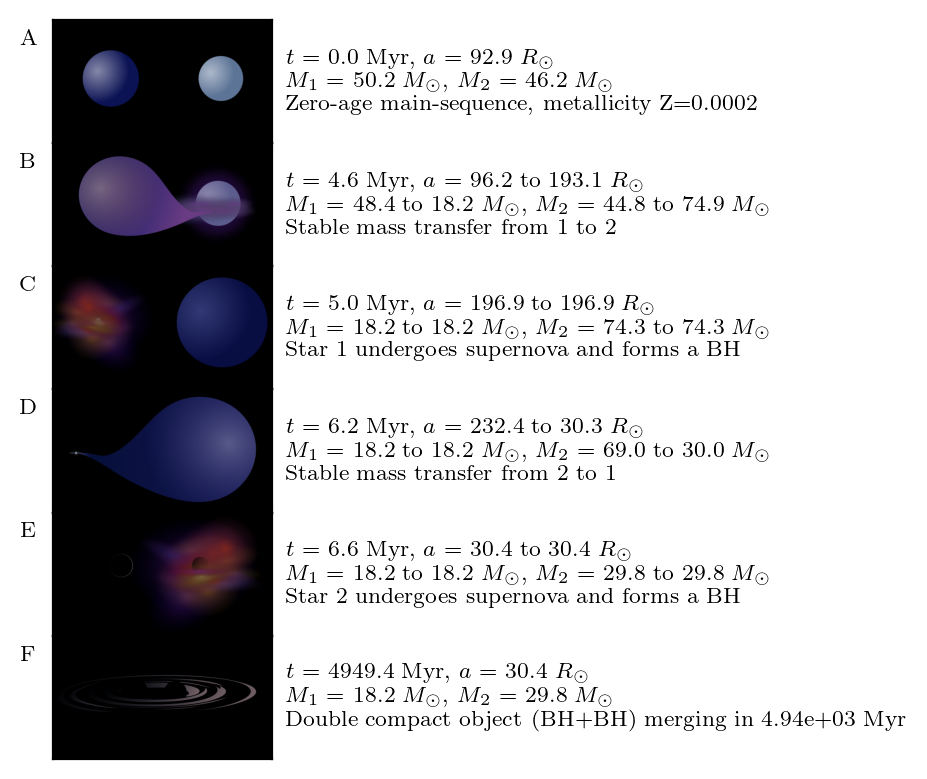

In [41]:
RawData = df_detailed_notides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
# print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [19]:
df_sanity_notides = pd.read_csv(notides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_notides = df_sanity_notides.rename(columns=lambda x: x.strip())

df_sanity_notides['SemiMajorAxis_Rsun'] = (df_sanity_notides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_notides['Period1'] = (2 * np.pi / (df_sanity_notides['Omega1'].values / u.yr)).to(u.day)
df_sanity_notides['Period2'] = (2 * np.pi / (df_sanity_notides['Omega2'].values / u.yr)).to(u.day)
df_sanity_notides['Period_orb'] = (2 * np.pi / (df_sanity_notides['Omega'].values / u.yr)).to(u.day)

df_sanity_notides_short = df_sanity_notides[columns_to_keep_sanity]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [20]:
st_change_idx = np.where((df_sanity_notides_short['StellarType_1'] != df_sanity_notides_short['StellarType_1'].shift()) | (df_sanity_notides_short['StellarType_2'] != df_sanity_notides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_notides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,50.2314,46.1816,6.898010,6.596870,0.000000e+00,31.7462,0.000000e+00,28.3392,0.000000e+00,4.124670,0.000000e+00,3.861550,92.919480,4.655360e-03,1,1,inf,inf,10.566430,0.000000,0.000000,975.783,0.000000,0.0000,5.525480e-07,4.440070e-07,5.525480e-07,4.440070e-07,0,0,0.000000e+00,0.000000e+00,4.959900e-08,3.655330e-08
1461,4.58706,48.3725,44.7929,18.087700,18.553100,0.000000e+00,18.1019,0.000000e+00,16.8202,0.000000e+00,1.346930,0.000000e+00,1.380310,96.158724,4.655360e-03,1,1,inf,inf,11.315961,0.000000,0.000000,943.186,0.000000,0.0000,3.315900e-13,4.014510e-13,3.315900e-13,4.014510e-13,0,0,0.000000e+00,0.000000e+00,1.845290e-06,1.819260e-06
1462,4.58706,48.3722,44.7928,17.579700,18.553100,2.847620e-276,18.1019,0.000000e+00,16.8201,5.353030e-138,1.346930,0.000000e+00,1.380300,96.158940,4.655360e-03,2,1,inf,inf,11.316017,0.000000,0.000000,943.183,0.000000,0.0000,3.823410e-13,4.014380e-13,3.823410e-13,4.014380e-13,0,0,inf,0.000000e+00,1.646520e-06,1.819210e-06
2110,4.58866,48.3711,44.7919,36.892600,18.575000,1.258800e-181,18.2415,0.000000e+00,16.8162,2.464130e-90,1.353240,0.000000e+00,1.379460,96.161090,4.655360e-03,2,1,inf,inf,11.316519,0.000000,0.000000,943.163,0.000000,0.0000,9.695910e-15,3.969690e-13,9.695910e-15,3.969690e-13,0,0,7.399950e-95,0.000000e+00,3.193150e-05,1.827570e-06
2111,4.58866,18.2416,74.9215,1.353250,12.431500,0.000000e+00,18.2416,0.000000e+00,40.0872,0.000000e+00,1.353250,0.000000e+00,3.476150,193.068341,0.000000e+00,7,1,inf,0.586569,32.194365,0.000000,97.971600,843.005,-30.129600,30.1296,0.000000e+00,-9.697510e-06,0.000000e+00,-9.697510e-06,0,0,0.000000e+00,0.000000e+00,8.184840e-13,-2.028980e-03
2288,5.03628,18.1586,74.3198,1.349490,14.307400,0.000000e+00,13.6446,0.000000e+00,37.3099,0.000000e+00,0.000071,0.000000e+00,3.020330,196.877206,0.000000e+00,7,1,inf,0.813270,33.274227,0.000000,92.843800,843.708,0.000000,0.0000,0.000000e+00,-6.135610e-07,0.000000e+00,-6.135610e-07,0,0,0.000000e+00,0.000000e+00,7.362020e-13,-1.446560e-03
2289,5.03628,18.1582,74.3175,1.349490,14.307100,0.000000e+00,13.6446,0.000000e+00,37.3086,0.000000e+00,0.000071,0.000000e+00,3.020260,196.891613,0.000000e+00,8,1,inf,0.813382,33.278377,0.000000,92.824600,843.709,0.000000,0.0000,0.000000e+00,-6.132860e-07,0.000000e+00,-6.132860e-07,0,0,0.000000e+00,0.000000e+00,7.359220e-13,-1.445850e-03
2289,5.03628,18.1582,74.3175,1.349490,14.307100,0.000000e+00,13.6446,0.000000e+00,37.3086,0.000000e+00,0.000071,0.000000e+00,3.020260,196.891613,0.000000e+00,8,1,inf,0.813382,33.278377,0.000000,92.824600,843.709,0.000000,0.0000,0.000000e+00,-6.132860e-07,0.000000e+00,-6.132860e-07,0,0,0.000000e+00,0.000000e+00,7.359220e-13,-1.445850e-03
2290,5.03777,18.1582,74.3171,0.000077,14.315000,0.000000e+00,18.1582,0.000000e+00,37.3003,0.000000e+00,0.000077,0.000000e+00,3.018800,196.894193,3.376610e-16,14,1,inf,0.814303,33.279101,0.000000,92.821300,843.712,0.000000,0.0000,0.000000e+00,-6.072520e-07,0.000000e+00,-6.072520e-07,0,0,0.000000e+00,0.000000e+00,7.796270e-30,-1.444550e-03
3335,6.23551,18.1582,71.6919,0.000077,23.420400,0.000000e+00,18.1582,0.000000e+00,29.6620,0.000000e+00,0.000077,0.000000e+00,1.817750,212.298452,3.376610e-16,14,1,inf,2.672468,37.800389,0.000000,73.031300,857.405,0.000000,0.0000,0.000000e+00,-2.702510e-11,0.000000e+00,-2.702510e-11,0,0,0.000000e+00,0.000000e+00,5.550790e-30,-3.621190e-04


### Perfect Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000046   Zero-age main-sequence, metallicity Z=0.0002   50.231     1     46.182     1     92.522  0.000
  4.587061   Star 1: MS->HG                    48.372     2     44.793     1     93.301  0.000
  4.588555   Stable mass transfer from 1 to 2   18.232     7     74.931     1    232.290  0.000
  4.588555   Star 1: HG->HeMS                  18.232     7     74.931     1    232.290  0.000
  5.036297   Star 1: HeMS->HeHG                18.150     8     74.329     1    233.806  0.000
  5.038042   Star 1 undergoes supernova and forms a BH   18.149    14     74.326     1    233.815  0.000
  6.235647   Star 2: MS->HG                    18.149    14     71.700     2    239.308  0.000
  6.237045   Stable mass transfer from 2 to 1   18.149    14     30.002     7     24.624  0.000
  6.237045   Star 2: HG->HeMS                  18.149    14     30.002     7     24.624  0.000
  6.579673   Star 2: HeMS->

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x16b72fe50>])

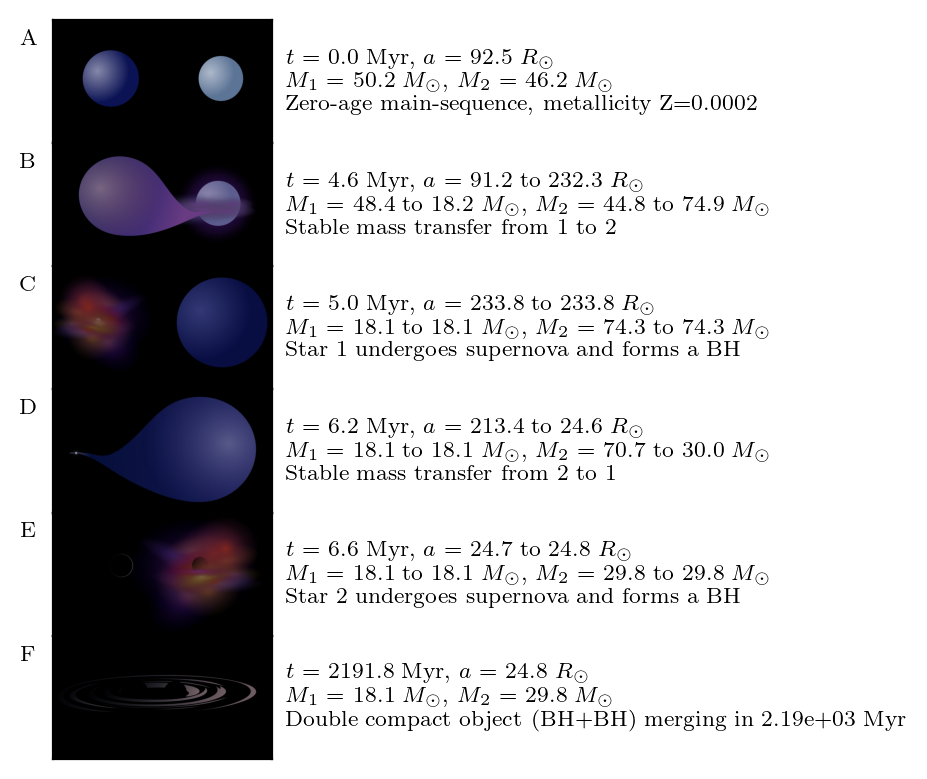

In [21]:
RawData = df_detailed_perfect
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
# print("Merges Hubble Time?:", df_dco_perfect['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [22]:
df_detailed_perfect['Period(1)'] = (2 * np.pi / (df_detailed_perfect['Omega(1)'].values / u.s)).to(u.day)
df_detailed_perfect['Period(2)'] = (2 * np.pi / (df_detailed_perfect['Omega(2)'].values / u.s)).to(u.day)

omega_orb = np.sqrt(c.G * (df_detailed_perfect['Mass(1)'].values * u.M_sun + df_detailed_perfect['Mass(2)'].values * u.M_sun) / (df_detailed_perfect['SemiMajorAxis'].values*u.AU)**3).to(1/u.s)
df_detailed_perfect['Omega_Orb'] = omega_orb.value
df_detailed_perfect['Period_Orb'] = (2 * np.pi / omega_orb).to(u.day)

df_detailed_perfect_short = df_detailed_perfect[columns_to_keep]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [23]:
# st_change_idx = np.where((df_detailed_perfect_short['Stellar_Type(1)'] != df_detailed_perfect_short['Stellar_Type(1)'].shift()) | (df_detailed_perfect_short['Stellar_Type(2)'] != df_detailed_perfect_short['Stellar_Type(2)'].shift()))[0]
# st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx+1])
# st_changes_with_buffer.sort()
# df_detailed_perfect_short.iloc[st_changes_with_buffer]


In [24]:
df_dco_perfect

NameError: name 'df_dco_perfect' is not defined

In [27]:
df_sanity_perfect = pd.read_csv(perfect_DataPath+'/sanity_checks.csv', header=0)
df_sanity_perfect = df_sanity_perfect.rename(columns=lambda x: x.strip())
df_sanity_perfect#[df_sanity_perfect['StellarType_2'] == 2]

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn
0,354788,0.000000,0.000046,1,1,975.783,975.783,975.783,973.703,0.000000e+00,1.129930e+00,0.000000,9.501110e-01,217.191,218.593,0.000,218.593,0.000000e+00,218.593,0.004655,0,50.2314,6.898010,5.169110e-03,5.169110e-03,46.1816,6.596870,4.346480e-03,4.346480e-03,0.432119,0.430270,8.702090e-08,6.992680e-08,8.702090e-08,6.992680e-08,5.525480e-07,4.440070e-07,1.629100e-06,1.309080e-06,8.702090e-08,6.992680e-08,8.702090e-08,6.992680e-08,5.525480e-07,4.440070e-07,1.629100e-06,1.309080e-06,0,0,0,0,0,0,0,0,31.7462,4.124670,28.3392,3.861550,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.436030e+05,2.893050e+05,9.218340,9.029630,-3.228320e-10,-2.455180e-10,7.048780e-05,6.375270e-05,-3.067240e-11,-2.332680e-11,1.338530e+01,1.51777,3.081260e-02,3.081260e-02,-0.000007,-5.366990e-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.811350e-09,5.756790e-09,7.811350e-09,5.756790e-09,4.959900e-08,3.655330e-08,1.462340e-07,1.077710e-07,-2.897870e-11,-2.021250e-11,-2.753280e-12,-1.920400e-12,6.327270e-06,5.248510e-06
1,354788,0.000046,0.009947,1,1,975.757,975.757,973.677,973.677,1.129710e+00,1.129810e+00,0.949950,9.500170e-01,218.581,218.581,218.561,218.581,2.185660e+02,218.581,0.000000,0,50.2300,6.897930,5.168850e-03,5.168850e-03,46.1804,6.596810,4.346290e-03,4.346290e-03,0.430282,0.430282,8.850000e-08,7.111630e-08,-8.845810e-08,-7.109010e-08,8.837910e-18,3.628340e-18,8.854200e-08,7.114250e-08,8.850000e-08,7.111630e-08,-8.845810e-08,-7.109010e-08,8.837910e-18,3.628340e-18,8.854200e-08,7.114250e-08,0,0,0,0,0,0,0,0,31.7448,4.124550,28.3382,3.861450,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.435850e+05,2.892920e+05,9.218260,9.029570,-5.280100e-21,-2.051570e-21,1.155790e-15,5.340720e-16,-0.000000e+00,-0.000000e+00,8.149120e+11,inf,1.891170e+09,1.891170e+09,-0.001479,-1.172420e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.944640e-09,5.855100e-09,-7.940880e-09,-5.852940e-09,7.933790e-19,2.987260e-19,7.948410e-09,5.857260e-09,-4.739940e-22,-1.689090e-22,-0.000000e+00,-0.000000e+00,1.037560e-16,4.397090e-17
2,354788,0.009992,0.009942,1,1,975.730,975.730,973.651,973.646,1.129590e+00,1.131960e+00,0.949855,9.517150e-01,218.569,218.571,218.114,218.571,2.181440e+02,218.571,0.000000,0,50.2285,6.904720,5.178880e-03,5.178880e-03,46.1792,6.602930,4.354250e-03,4.354250e-03,0.430294,0.430290,8.699890e-08,6.996910e-08,-8.603820e-08,-6.924720e-08,3.882990e-14,2.603550e-14,8.796630e-08,7.069570e-08,8.699890e-08,6.996910e-08,-8.603820e-08,-6.924720e-08,3.882990e-14,2.603550e-14,8.796630e-08,7.069570e-08,0,0,0,0,0,0,0,0,31.7158,4.118480,28.3136,3.856030,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.440270e+05,2.896490e+05,9.216690,9.028170,-2.330910e-17,-1.478720e-17,5.092110e-12

In [28]:
df_sanity_perfect['SemiMajorAxis_Rsun'] = (df_sanity_perfect['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_perfect['Period1'] = (2 * np.pi / (df_sanity_perfect['Omega1'].values / u.yr)).to(u.day)
df_sanity_perfect['Period2'] = (2 * np.pi / (df_sanity_perfect['Omega2'].values / u.yr)).to(u.day)
df_sanity_perfect['Period_orb'] = (2 * np.pi / (df_sanity_perfect['Omega'].values / u.yr)).to(u.day)


df_sanity_perfect_short = df_sanity_perfect[columns_to_keep_sanity]

In [29]:
st_change_idx = np.where((df_sanity_perfect_short['StellarType_1'] != df_sanity_perfect_short['StellarType_1'].shift()) | (df_sanity_perfect_short['StellarType_2'] != df_sanity_perfect_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_perfect_short.iloc[st_changes_with_buffer][1:]


,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,50.2314,46.1816,6.898010,6.596870,0.000000e+00,31.7462,0.000000e+00,28.3392,0.000000e+00,4.124670,0.000000e+00,3.861550,92.521886,0,1,1,10.498659,10.498659,10.498659,1.129930e+00,9.501110e-01,973.703,0.000000,0.0000,5.525480e-07,4.440070e-07,5.525480e-07,4.440070e-07,0,0,0.000000e+00,0.000000e+00,4.959900e-08,3.655330e-08
1461,4.58706,48.3725,44.7929,18.087700,18.553100,0.000000e+00,18.1019,0.000000e+00,16.8202,0.000000e+00,1.346930,0.000000e+00,1.380310,93.300517,0,1,1,10.815210,10.815210,10.815210,7.262590e+00,7.075710e+00,929.073,0.000000,0.0000,-1.273500e-20,3.847630e-24,-1.273500e-20,3.847630e-24,0,0,0.000000e+00,0.000000e+00,-7.086980e-14,1.743630e-17
1462,4.58706,48.3722,44.7928,17.579700,18.553100,2.847620e-276,18.1019,0.000000e+00,16.8201,5.353030e-138,1.346930,0.000000e+00,1.380300,93.914434,0,2,1,10.922117,10.922117,10.922117,4.282370e+00,7.006410e+00,932.120,0.000000,0.0000,-1.538020e-13,1.833350e-27,-1.538020e-13,1.833350e-27,0,0,-inf,0.000000e+00,-6.623320e-07,8.308230e-21
2061,4.58855,48.3712,44.7920,35.146900,18.573600,7.652100e-187,18.2324,0.000000e+00,16.8164,5.777050e-93,1.352830,0.000000e+00,1.379520,91.160302,0,2,1,10.445332,10.445332,10.445332,1.772380e+01,7.342290e+00,918.324,0.000000,0.0000,1.503410e-22,1.811760e-28,1.503410e-22,1.811760e-28,0,0,1.753850e-100,0.000000e+00,3.207270e-13,8.332410e-22
2062,4.58855,18.2324,74.9307,1.352830,12.431300,0.000000e+00,18.2324,0.000000e+00,40.0944,0.000000e+00,1.352830,0.000000e+00,3.476770,232.290636,0,7,1,42.487201,42.487201,42.487201,3.897970e-03,1.352680e+00,924.327,-30.138700,30.1387,0.000000e+00,-9.687770e-06,0.000000e+00,-9.687770e-06,0,0,0.000000e+00,0.000000e+00,-5.357130e-12,-2.024140e-03
2239,5.03630,18.1495,74.3288,1.349080,14.307400,0.000000e+00,13.6368,0.000000e+00,37.3158,0.000000e+00,0.000071,0.000000e+00,3.020760,233.806613,0,7,1,43.062487,43.062487,43.062487,3.807210e-03,1.753660e+00,919.091,0.000000,0.0000,0.000000e+00,2.930870e-20,0.000000e+00,2.930870e-20,0,0,0.000000e+00,0.000000e+00,-2.109760e-20,6.904230e-17
2240,5.03630,18.1492,74.3265,1.349080,14.307200,0.000000e+00,13.6369,0.000000e+00,37.3146,0.000000e+00,0.000071,0.000000e+00,3.020690,233.815214,0,8,1,43.065396,43.065396,43.065396,9.464750e-04,1.753430e+00,919.075,0.000000,0.0000,0.000000e+00,2.137300e-22,0.000000e+00,2.137300e-22,0,0,0.000000e+00,0.000000e+00,-7.040390e-12,5.034600e-19
2240,5.03630,18.1492,74.3265,1.349080,14.307200,0.000000e+00,13.6369,0.000000e+00,37.3146,0.000000e+00,0.000071,0.000000e+00,3.020690,233.815214,0,8,1,43.065396,43.065396,43.065396,9.464750e-04,1.753430e+00,919.075,0.000000,0.0000,0.000000e+00,2.137300e-22,0.000000e+00,2.137300e-22,0,0,0.000000e+00,0.000000e+00,-7.040390e-12,5.034600e-19
2241,5.03779,18.1492,74.3261,0.000077,14.315100,0.000000e+00,18.1492,0.000000e+00,37.3063,0.000000e+00,0.000077,0.000000e+00,3.019230,233.815214,0,14,1,43.065720,43.065720,43.065720,4.954430e-11,1.755340e+00,919.073,0.000000,0.0000,0.000000e+00,2.229690e-19,0.000000e+00,2.229690e-19,0,0,0.000000e+00,0.000000e+00,-1.019380e-10,5.299690e-16
3286,6.23565,18.1492,71.6999,0.000077,23.422000,0.000000e+00,18.1492,0.000000e+00,29.6657,0.000000e+00,0.000077,0.000000e+00,1.817890,239.309286,0,14,1,45.239261,45.239261,45.239261,4.716390e-11,4.315350e+00,909.967,0.000000,0.0000,0.000000e+00,-8.533790e-22,0.000000e+00,-8.533790e-22,0,0,0.000000e+00,0.000000e+00,-3.943440e-49,-1.143800e-14


# CE binary not able to spin up

In [17]:
notides_DataPath = 'sim_data/ce_notides'
tides_DataPath = 'sim_data/ce_realistic'
perfect_DataPath = 'sim_data/ce_perfect'
# perfect_DataPath = 'sim_data/ce_z77'

# # --------------

df_detailed_notides = pd.read_csv(notides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_notides = df_detailed_notides.rename(columns=lambda x: x.strip())

df_detailed_tides = pd.read_csv(tides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0, low_memory=False)
df_detailed_tides = df_detailed_tides.rename(columns=lambda x: x.strip())

df_detailed_perfect = pd.read_csv(perfect_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0, low_memory=False)
df_detailed_perfect = df_detailed_perfect.rename(columns=lambda x: x.strip())



df_dco_notides = pd.read_csv(notides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_notides = df_dco_notides.rename(columns=lambda x: x.strip())

df_dco_tides = pd.read_csv(tides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_tides = df_dco_tides.rename(columns=lambda x: x.strip())

df_dco_perfect = pd.read_csv(perfect_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_perfect = df_dco_perfect.rename(columns=lambda x: x.strip())


### Realistic Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000049   Zero-age main-sequence, metallicity Z=0.0027   44.320     1     42.224     1   1571.140  0.013
  5.009339   Star 1: MS->HG                    40.893     2     39.305     1   1695.456  0.013
  5.014853   Star 1: HG->CHeB                  14.815     4     39.301     1   2512.637  0.013
  5.029927   Star 1: CHeB->HeMS                14.799     7     39.289     1   2513.919  0.013
  5.164346   Star 2: MS->HG                    14.739     7     39.185     2   2521.553  0.013
  5.170179   Star 2: HG->CHeB                  14.736     7     39.142     4   2523.703  0.013
  5.251990   Common envelope initiated by 2    14.696     7     14.338     7      8.877  0.000
  5.251990   Star 2: CHeB->HeMS                14.696     7     14.338     7      8.877  0.000
  5.521499   Star 1: HeMS->HeHG                14.540     8     14.212     7      8.921  0.000
  5.531175   Star 1 undergoes supernova

(<Figure size 900x480 with 5 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x16eeafb90>])

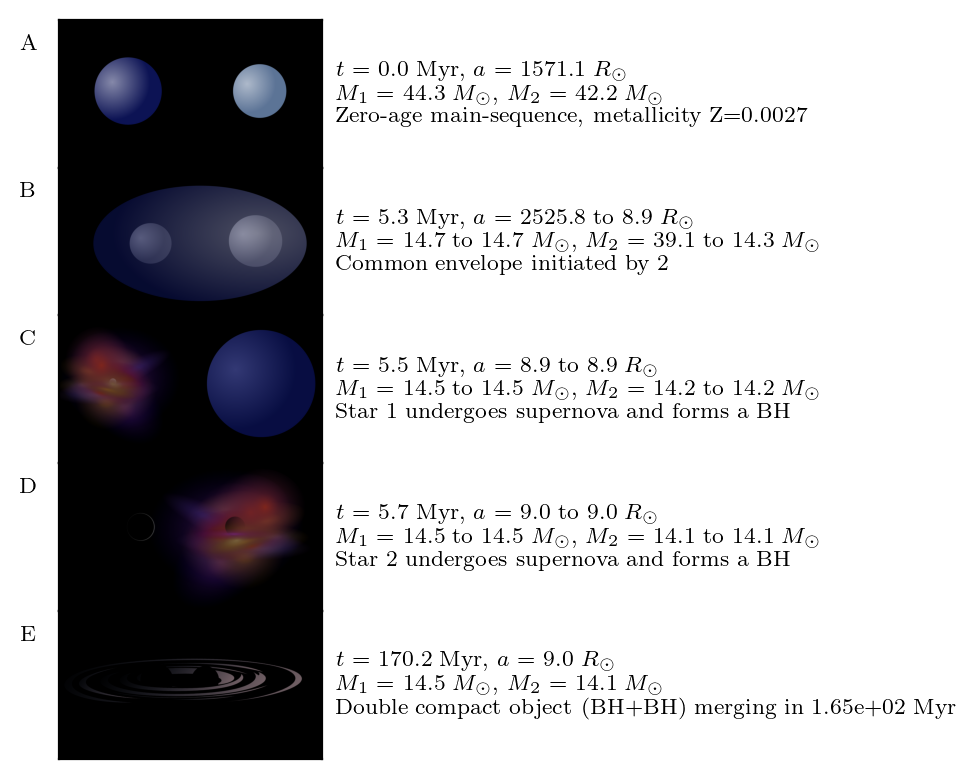

In [18]:
RawData = df_detailed_tides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [19]:
df_ce_tides = pd.read_csv(tides_DataPath+'/BSE_Common_Envelopes.csv', skiprows=2, header=0)
df_ce_tides = df_ce_tides.rename(columns=lambda x: x.strip())

df_ce_tides

,SEED,Time,Lambda@CE(1),Lambda@CE(2),Binding_Energy<CE(1),Binding_Energy<CE(2),Eccentricity<CE,Eccentricity>CE,SemiMajorAxis<CE,SemiMajorAxis>CE,SemiMajorAxisStage1>CE,RocheLobe(1)<CE,RocheLobe(1)>CE,RocheLobe(2)<CE,RocheLobe(2)>CE,Mass(1)<CE,Mass(1)>CE,Mass_Env(1),Radius(1)<CE,Radius(1)>CE,Stellar_Type(1)<CE,Stellar_Type(1),Lambda_Convective(1),Lambda_Fixed(1),Lambda_Nanjing(1),Lambda_Loveridge(1),Lambda_Loveridge_Winds(1),Lambda_Kruckow(1),BE_Fixed(1),BE_Nanjing(1),BE_Loveridge(1),BE_Loveridge_Winds(1),BE_Kruckow(1),Mass_Convective_Env(1),Mass(2)<CE,Mass(2)>CE,Mass_Env(2),Radius(2)<CE,Radius(2)>CE,Stellar_Type(2)<CE,Stellar_Type(2),Lambda_Convective(2),Lambda_Fixed(2),Lambda_Nanjing(2),Lambda_Loveridge(2),Lambda_Loveridge_Winds(2),Lambda_Kruckow(2),BE_Fixed(2),BE_Nanjing(2),BE_Loveridge(2),BE_Loveridge_Winds(2),BE_Kruckow(2),Mass_Convective_Env(2),MT_History,Merger,Optimistic_CE,CE_Event_Counter,Double_Core_CE,RLOF(1),Luminosity<CE(1),Teff<CE(1),Tau_Dynamical<CE(1),Tau_Thermal<CE(1),RLOF(2),Luminosity<CE(2),Teff<CE(2),Tau_Dynamical<CE(2),Tau_Thermal<CE(2),Zeta_Star,Zeta_Lobe,Tau_Sync(1),Tau_Sync(2),Tau_Circ,Tau_Radial<CE(1),Tau_Radial<CE(2),Immediate_RLOF>CE,Simultaneous_RLOF,Record_Type
0,52979,5.251973,0.62551,0.071142,1036597636813855068153286902458613775863676456...,4459676650750934223904789847203424007529818593...,0.0,0.0,2494.099726,8.877966,0.0,743.5544,3.383001,1161.002671,3.345119,14.695562,14.695562,0.0,1.263997,1.263997,7,7,0.978449,0.1,0.62551,1.0,1.0,15.881659,6484023382326382892725788424376629001302692375...,1036597636813855068153286902458613775863676456...,6484023382326383557339786316834565453206222515...,6484023382326383557339786316834565453206222515...,4082711620959656091559337164597031053330532741...,0.0,39.138451,14.33781,24.800641,1161.067888,1.194723,4,7,0.976492,0.1,0.616852,1.0,1.0,16.489794,6530055475471253131652347187402867426308886460...,1058609862752967086503424269860097432051528696...,6530055475471253796266345079860803878212416600...,6530055475471253796266345079860803878212416600...,3960058859883399906908123865286777204539720414...,0.0,4,0,0,1,0,0,346648.538055,124702.967341,1.853500e-11,0.015476,1,593030.900486,4705.633094,3.161947e-07,0.000044,0.256975,2.811411,3.347835e+17,25821495894091153539072.000000000000000,28445925851039824609280.000000000000000,4.359588,0.033542,0,0,1


In [20]:
df_sanity_tides = pd.read_csv(tides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_tides = df_sanity_tides.rename(columns=lambda x: x.strip())

df_sanity_tides['SemiMajorAxis_Rsun'] = (df_sanity_tides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_tides['Period1'] = (2 * np.pi / (df_sanity_tides['Omega1'].values / u.yr)).to(u.day)
df_sanity_tides['Period2'] = (2 * np.pi / (df_sanity_tides['Omega2'].values / u.yr)).to(u.day)
df_sanity_tides['Period_orb'] = (2 * np.pi / (df_sanity_tides['Omega'].values / u.yr)).to(u.day)

df_sanity_tides_short = df_sanity_tides[columns_to_keep_sanity]

df_sanity_tides.iloc[np.where(df_sanity_tides['StellarType_2'] == 7)]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn,SemiMajorAxis_Rsun,Period1,Period2,Period_orb
10746,52979,5.25197,0.000016,7,7,49.9235,49.9235,49.9235,49.9217,0.000000,0.000053,0.000000,0.001786,4035.65,4036.10,0.000000e+00,1.034960e+00,0.0000,40.3572,0.000000e+00,0.000000e+00,14.6956,1.264000,5.077760e-05,5.077760e-05,14.3378,1.19472,0.000044,0.000044,0.041287,0.041284,3.228050e-07,1.384410e-05,3.228050e-07,1.384410e-05,0.000002,8.790430e-05,0.000006,2.591710e-04,3.228050e-07,1.384410e-05,3.228050e-07,1.384410e-05,0.000002,8.790430e-05,0.000006,2.591710e-04,0,0,0,0,0,0,0,0,11.3128,0.671128,13.1444,1.009790,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.466490e+05,292967.0,21.582400,21.2849,-5.847790e-08,-1.987590e-06,0.696282,2.715070e+01,-0.0,-0.000000e+00,2.077220e-04,inf,1.486390e-06,1.486390e-06,0.000000,0.000000e+00,0,-24.8006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.347840e-09,2.574670e-09,3.347840e-09,2.574670e-09,2.125740e-08,1.634810e-08,6.267410e-08,4.819980e-08,-6.064800e-10,-3.696450e-10,-0.000000e+00,-0.000000e+00,7.221200e-03,0.005049,8.877302,2.217413e+03,56.865527,0.568602
10747,52979,5.25199,0.003609,7,7,49.9178,49.9178,49.9159,49.9141,0.000053,0.000106,0.001785,0.003571,4035.17,4035.61,1.034360e+00,2.096380e+00,40.3382,80.6906,0.000000e+00,0.000000e+00,14.6937,1.263910,5.076420e-05,5.076420e-05,14.3363,1.19465,0.000044,0.000044,0.041288,0.041285,3.225010e-07,1.383400e-05,3.220610e-07,1.310870e-05,0.000002,8.551860e-05,0.000006,2.544070e-04,3.225010e-07,1.383400e-05,3.220610e-07,1.310870e-05,0.000002,8.551860e-05,0.000006,2.544070e-04,0,0,0,0,0,0,0,0,11.3111,0.671041,13.1428,1.009690,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.465740e+05,292916.0,21.582000,21.2846,-5.834770e-08,-1.932500e-06,0.694781,2.639880e+01,-0.0,-0.000000e+00,2.136530e-04,inf,1.528540e-06,1.528540e-06,-0.001862,-1.481460e-03,0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.345210e-09,2.572860e-09,3.340640e-09,2.437960e-09,2.122630e-08,1.590480e-08,6.259640e-08,4.731460e-08,-6.052230e-10,-3.594060e-10,-0.000000e+00,-0.000000e+00,7.206750e-03,0.004910,8.877689,1.094713e+03,28.441150,0.568671
10748,52979,5.25560,0.003609,7,7,49.9120,49.9120,49.9084,49.9065,0.000106,0.000159,0.003568,0.005357,4034.68,4035.13,2.091730e+00,3.130690e+00,80.4921,120.8400,0.000000e+00,0.000000e+00,14.6918,1.264860,5.083390e-05,5.083390e-05,14.3348,1.19578,0.000044,0.000044,0.041290,0.041287,2.878000e-07,1.294710e-05,2.870040e-07,1.161500e-05,0.000002,7.790810e-05,0.000005,2.338790e-04,2.878000e-07,1.294710e-05,2.870040e-07,1.161500e-05,0.000002,7.790810e-05,0.000005,2.338790e-04,0,0,0,0,0,0,0,0,11.2674,0.662526,13.0891,1.002240,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.474140e+05,293727.0,21.586900,21.2893,-5.221460e-08

In [21]:
st_change_idx = np.where((df_sanity_tides_short['StellarType_1'] != df_sanity_tides_short['StellarType_1'].shift()) | (df_sanity_tides_short['StellarType_2'] != df_sanity_tides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_tides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,44.3196,42.2241,7.630870,7.41979,0.000000e+00,26.8083,0.000000e+00,25.11090,0.000000e+00,3.738000,0.000000e+00,3.596840,1571.138896,1.253860e-02,1,1,inf,inf,775.425376,0.000000,0.000000,3416.1800,0,0.0000,1.825170e-12,1.620420e-12,1.825170e-12,1.620420e-12,0,0,0.0,0.000000e+00,6.515990e-13,5.414470e-13
1565,5.00934,40.8929,39.3052,20.623900,23.02830,0.000000e+00,14.4288,0.000000e+00,13.94310,0.000000e+00,1.172920,0.000000e+00,1.201040,1695.455437,1.253860e-02,1,1,inf,inf,902.990948,0.000000,0.000000,3166.3100,0,0.0000,5.679560e-19,4.239350e-19,5.679560e-19,4.239350e-19,0,0,0.0,0.000000e+00,2.051760e-11,3.004570e-11
1566,5.00934,40.8925,39.3049,20.111200,23.02820,2.358750e-218,14.4288,0.000000e+00,13.94300,6.166100e-109,1.172920,0.000000e+00,1.201040,1695.470489,1.253860e-02,2,1,inf,inf,903.005160,0.000000,0.000000,3166.2800,0,0.0000,6.441130e-19,4.239110e-19,6.441130e-19,4.239110e-19,0,0,inf,0.000000e+00,1.855100e-11,3.004370e-11
4985,5.01485,14.8145,39.3009,66.933500,23.14490,0.000000e+00,14.7173,0.000000e+00,13.93160,0.000000e+00,1.187190,0.000000e+00,1.198590,2512.629236,1.253860e-02,2,1,inf,inf,1983.212148,0.000000,0.000000,1699.7600,0,0.0000,2.101870e-22,4.984930e-20,2.101870e-22,4.984930e-20,0,0,0.0,0.000000e+00,6.048870e-11,3.761140e-12
4986,5.01485,14.8067,39.3001,7.621120,23.14450,0.000000e+00,14.7173,0.000000e+00,13.93120,0.000000e+00,1.187200,0.000000e+00,1.198570,2513.037797,1.253860e-02,4,1,inf,inf,1983.846469,0.000000,0.000000,1699.1000,0,0.0000,1.097410e-17,4.980570e-20,1.097410e-17,4.980570e-20,0,0,0.0,0.000000e+00,1.015000e-14,3.757590e-12
6458,5.02890,14.7985,39.2893,1.195800,23.44780,0.000000e+00,14.7973,0.000000e+00,13.90190,0.000000e+00,1.195780,0.000000e+00,1.192330,2513.919429,1.253860e-02,4,1,inf,inf,1985.236534,0.000000,0.000000,1698.2900,0,0.0000,0.000000e+00,4.456580e-20,0.000000e+00,4.456580e-20,0,0,0.0,0.000000e+00,6.135380e-18,3.949390e-12
6459,5.02993,14.7981,39.2885,1.196160,23.47030,0.000000e+00,14.5594,0.000000e+00,13.89980,0.000000e+00,1.161010,0.000000e+00,1.191870,2513.983938,1.253860e-02,7,1,inf,inf,1985.322404,0.000000,0.000000,1698.2500,0,0.0000,9.543700e-14,4.420390e-20,9.543700e-14,4.420390e-20,0,0,0.0,0.000000e+00,6.141840e-18,3.963960e-12
6801,5.16435,14.7390,39.1851,1.238380,19.87280,0.000000e+00,12.4807,0.000000e+00,13.62110,0.000000e+00,0.872126,0.000000e+00,1.132330,2521.553070,1.253860e-02,7,1,inf,inf,1997.313717,0.000000,0.000000,1692.0900,0,0.0000,7.384270e-15,6.474410e-20,7.384270e-15,6.474410e-20,0,0,0.0,0.000000e+00,6.901970e-18,1.997100e-12
6802,5.16435,14.7388,39.1847,1.238380,19.39420,0.000000e+00,12.4806,1.950020e-217,13.62110,0.000000e+00,0.872119,1.740540e-108,1.132330,2521.574573,1.253860e-02,7,2,inf,inf,1997.348483,0.000000,0.000000,1692.0800,0,0.0000,7.383650e-15,7.313240e-20,7.383650e-15,7.313240e-20,0,0,0.0,inf,6.901360e-18,1.811440e-12
9925,5.17018,14.7362,39.1419,1.240180,517.78000,0.000000e+00,12.3975,3.146150e-24,13.89350,0.000000e+00,0.859074,1.979820e-10,1.146120,2523.703392,1.253860e-02,7,2,inf,inf,2000.726589,0.000000,0.000000,1691.3500,0,0.0000,6.428760e-15,5.829890e-27,6.428760e-15,5.829890e-27,0,0,0.0,1.289120e-15,6.908630e-18,9.146390e-07


In [25]:
st_labels[4]

'CHeB'

#### Breakdown by tidal mechanism

In [27]:
# Load full data for tidal breakdown
rc = df_sanity_tides["R1_core"].values * u.R_sun              # Rsol
R = df_sanity_tides["R1"].values * u.R_sun                    # Rsol
Renv = df_sanity_tides["R1_conv_env_extent"].values * u.R_sun # Rsol
Rint = R - Renv

rc2 = df_sanity_tides["R2_core"].values * u.R_sun              # Rsol
R2 = df_sanity_tides["R2"].values * u.R_sun                    # Rsol
Renv2 = df_sanity_tides["R2_conv_env_extent"].values * u.R_sun # Rsol
Rint2 = R2 - Renv2

L = df_sanity_tides["Lum_1"].values * u.L_sun                 # Lsol
L2 = df_sanity_tides["Lum_2"].values * u.L_sun                 # Lsol

M = df_sanity_tides["M1"].values * u.M_sun                    # Msol
Mc = df_sanity_tides["M1_core"].values * u.M_sun              # Msol
Menv = df_sanity_tides["M1_conv_env"].values * u.M_sun        # Msol

M2 = df_sanity_tides["M2"].values * u.M_sun                   # Msol
Mc2 = df_sanity_tides["M2_core"].values * u.M_sun              # Msol
Menv2 = df_sanity_tides["M2_conv_env"].values * u.M_sun        # Msol


I1 = df_sanity_tides["I1_before"].values * u.M_sun * u.AU**2  # Msol * AU^2

tau_conv = df_sanity_tides["tau_conv1"].values * u.yr                # yr
tau_conv2 = df_sanity_tides["tau_conv2"].values * u.yr                # yr


omega_orb = df_sanity_tides["Omega_before"].values / u.yr     # 1/yr
omega_spin = df_sanity_tides["Omega1_before"].values / u.yr   # 1/yr
omega_spin2 = df_sanity_tides["Omega2_before"].values / u.yr   # 1/yr

sma = df_sanity_tides["SemiMajorAxis_before"].values * u.AU   # AU
ecc = df_sanity_tides["ecc_before"].values                           # 1
period_orb = 2 * np.pi / df_sanity_tides["Omega_before"].values * u.yr.to(u.day) * u.day     # days

Imk10 = df_sanity_tides["ImK10_1"].values
Imk12 = df_sanity_tides["ImK12_1"].values
Imk22 = df_sanity_tides["ImK22_1"].values
Imk32 = df_sanity_tides["ImK32_1"].values

Imk10_dyn = df_sanity_tides["ImK10_1_dyn"].values
Imk12_dyn = df_sanity_tides["ImK12_1_dyn"].values
Imk22_dyn = df_sanity_tides["ImK22_1_dyn"].values
Imk32_dyn = df_sanity_tides["ImK32_1_dyn"].values

Imk10_eq = df_sanity_tides["ImK10_1_eq"].values
Imk12_eq = df_sanity_tides["ImK12_1_eq"].values
Imk22_eq = df_sanity_tides["ImK22_1_eq"].values
Imk32_eq = df_sanity_tides["ImK32_1_eq"].values

Imk10_2 = df_sanity_tides["ImK10_2"].values
Imk12_2 = df_sanity_tides["ImK12_2"].values
Imk22_2 = df_sanity_tides["ImK22_2"].values
Imk32_2 = df_sanity_tides["ImK32_2"].values

Imk10_2_dyn = df_sanity_tides["ImK10_2_dyn"].values
Imk12_2_dyn = df_sanity_tides["ImK12_2_dyn"].values
Imk22_2_dyn = df_sanity_tides["ImK22_2_dyn"].values
Imk32_2_dyn = df_sanity_tides["ImK32_2_dyn"].values

Imk10_2_eq = df_sanity_tides["ImK10_2_eq"].values
Imk12_2_eq = df_sanity_tides["ImK12_2_eq"].values
Imk22_2_eq = df_sanity_tides["ImK22_2_eq"].values
Imk32_2_eq = df_sanity_tides["ImK32_2_eq"].values

dadt = df_sanity_tides["dadt1"].values * u.AU / u.yr
dOmegadt = df_sanity_tides["dOmegadt1"].values / u.yr**2
dedt1 = df_sanity_tides["dedt1"].values / u.yr


G_AU_Msol_yr = c.G.to(u.AU**3 / u.M_sun / u.yr**2)
Time = df_sanity_tides["Time"].values * 1e6 * u.yr          # yr
st1 = df_sanity_tides["StellarType_1"].values
st2 = df_sanity_tides["StellarType_2"].values

rc_AU = df_sanity_tides["R1_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU = df_sanity_tides["R1_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU = df_sanity_tides["R1"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU = R_AU - Renv_AU                  
Mint = M - Mc - Menv     


rc_AU2 = df_sanity_tides["R2_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU2 = df_sanity_tides["R2_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU2 = df_sanity_tides["R2"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU2 = R_AU2 - Renv_AU2                 
Mint2 = M2 - Mc2 - Menv2    

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR', 'CHE', '--', '--', 'None']

In [28]:
print("Equilibrium tides from turbulent viscosity:")
Imk22_eq[st_changes_with_buffer][1:]

Equilibrium tides from turbulent viscosity:


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [32]:
rc_AU/R_AU

<Quantity [0.55570165, 0.55568938, 0.55421258, ..., 1.        , 1.        ,
           1.        ]>

In [29]:
print("IGW dissipation from convective core -- radiative envelope boundary:")
E2_kushnir = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.)
l=2
m=2
imk22_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk22_core_gw[(rc_AU/R_AU < frac_limit) | (Mc/M < frac_limit) | (Menv/M > frac_limit) | (Renv/R_AU > frac_limit)] = 0.0
imk22_core_gw[np.isnan(imk22_core_gw)] = 0.0
imk22_core_gw[st_changes_with_buffer][1:]

0.1 * (2./3.) * (R_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)

IGW dissipation from convective core -- radiative envelope boundary:


/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [9.71532992e-08, 9.71389776e-08, 9.76395242e-08, ...,
           7.51381750e-20, 7.51366991e-20, 7.51352231e-20]>

In [30]:
print("IGW dissipation from radiative zone -- convective shell boundary:")

dNlnr_cbrt = (G_AU_Msol_yr * Mint / (Rint_AU**2 * (R_AU - Rint_AU)))**(1/3)

alpha = Rint_AU/R_AU
beta = Mint/M

# one_minus_beta = 1-beta
one_minus_beta = Menv/M

# gamma = alpha**3 * (1-beta) / (beta * (1 - alpha**3))
rho_conv = Menv / (4 * np.pi * (R_AU**3 - Rint_AU**3))
rho_rad = Mint / (4 * np.pi * (Rint_AU**3 - rc_AU**3))
gamma = rho_conv / rho_rad

Epsilon = alpha**11 * (one_minus_beta) * (1-gamma)**2 * (2*alpha/3 - 1)**2 / (beta**2 * (1-alpha**3) * (1-alpha)**2)


l=2
m=2
imk22_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) * (2*(2+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk22_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk22_env_gw)
imk22_env_gw[(Renv_AU/R_AU < frac_limit) | (Menv/M < frac_limit)] = 0.0
imk22_env_gw[np.isnan(imk22_env_gw)] = 0.0

imk22_env_gw[st_changes_with_buffer][1:]

IGW dissipation from radiative zone -- convective shell boundary:


/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0.]>

In [31]:
print("Dynamical tides from inertial wave dissipation:")
alpha = Rint_AU/R_AU
beta = Mint/M
one_minus_beta = Menv/M

rho_conv = Menv / ((R_AU**3 - Rint_AU**3))
rho_rad = Mint / ((Rint_AU**3 - rc_AU**3))
gamma = rho_conv / rho_rad

eps = omega_spin / np.sqrt(G_AU_Msol_yr * M / R_AU**3)

b1 = (1 + 2*alpha + 3*alpha**2 + (3/2)*alpha**3)
b2 = 1 + ((1-gamma) / gamma) * alpha**3
b3 = 1 + (3*gamma/2) + ((5*alpha**3)/(2*gamma))*(1 + gamma/2 - (3*gamma**2)/2) - (9/4)*(1-gamma)*alpha**5
imk22_inertial = (100 * np.pi / 63) * eps**2 * (alpha**5 / (1 - alpha**5)) * (1-gamma)**2 * (1-alpha)**4 * b1**2 * b2 * b3**(-2)

imk22_inertial[((Renv_AU/R_AU < frac_limit) & (Menv/M < frac_limit)) | (omega_orb > 2*omega_spin) | (Mint/M < frac_limit)] = 0.0
imk22_inertial = np.sign(omega_orb - omega_spin) * np.abs(imk22_inertial)
imk22_inertial[np.isnan(imk22_inertial)] = 0.0

imk22_inertial[st_changes_with_buffer][1:]

Dynamical tides from inertial wave dissipation:


/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in subtract
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0., -0., -0., -0., -0.,
           -0.,  0.,  0.,  0.,  0.,  0.]>

### Notides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000117   Zero-age main-sequence, metallicity Z=0.0004   17.316     1     15.053     1    468.801  0.196
 11.746292   Star 1: MS->HG                    17.215     2     15.012     1    470.860  0.196
 11.770278   Star 1: HG->CHeB                  17.215     4     15.012     1    470.869  0.196
 12.697120   Stable mass transfer from 1 to 2    6.092     7     17.278     1    994.058  0.000
 12.697120   Star 1: CHeB->HeMS                 6.092     7     17.278     1    994.058  0.000
 12.886784   Star 1: HeMS->HeHG                 6.088     8     17.275     1    994.407  0.000
 12.943790   Star 1 undergoes supernova and forms a BH    4.432    14     17.275     1   1076.565  0.076
 15.216862   Star 2: MS->HG                     4.432    14     17.241     2   1079.203  0.076
 15.240776   Star 2: HG->CHeB                   4.432    14     17.240     4   1079.248  0.076
 16.356683   Common envelope

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x16b0c44d0>])

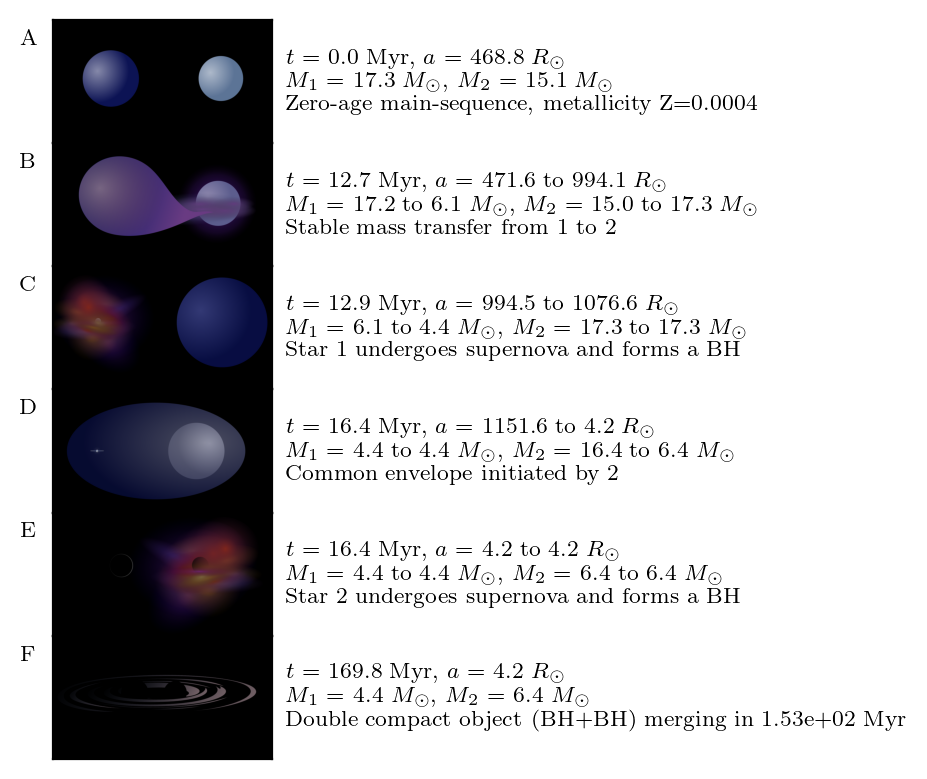

In [11]:
RawData = df_detailed_notides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [51]:
st_labels[7]

'HeMS'

In [32]:
df_sanity_notides = pd.read_csv(notides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_notides = df_sanity_notides.rename(columns=lambda x: x.strip())

df_sanity_notides['SemiMajorAxis_Rsun'] = (df_sanity_notides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_notides['Period1'] = (2 * np.pi / (df_sanity_notides['Omega1'].values / u.yr)).to(u.day)
df_sanity_notides['Period2'] = (2 * np.pi / (df_sanity_notides['Omega2'].values / u.yr)).to(u.day)
df_sanity_notides['Period_orb'] = (2 * np.pi / (df_sanity_notides['Omega'].values / u.yr)).to(u.day)

df_sanity_notides_short = df_sanity_notides[columns_to_keep_sanity]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [33]:
st_change_idx = np.where((df_sanity_notides_short['StellarType_1'] != df_sanity_notides_short['StellarType_1'].shift()) | (df_sanity_notides_short['StellarType_2'] != df_sanity_notides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_notides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,26.70760,24.13840,4.800230,4.521210,0.000000e+00,13.53120,0.000000e+00,11.80580,0.000000e+00,2.467860,0.000000e+00,2.263780,502.452736,3.941130e-02,1,1,inf,inf,182.957981,0,0.000000,867.6690,0.000,0.00000,5.169080e-11,3.846470e-11,5.169080e-11,3.846470e-11,0,0,0.000000e+00,0.000000e+00,2.237830e-12,1.512230e-12
1288,7.30215,26.37570,23.93700,11.701300,10.037000,0.000000e+00,7.98290,0.000000e+00,7.43831,0.000000e+00,0.814986,0.000000e+00,0.890561,507.779083,3.941130e-02,1,1,inf,inf,186.856441,0,0.000000,858.7440,0.000,0.00000,5.360000e-17,2.817450e-16,5.360000e-17,2.817450e-16,0,0,0.000000e+00,0.000000e+00,7.330040e-11,3.428490e-11
1289,7.30215,26.37560,23.93700,11.495300,10.037000,2.933610e-259,7.98290,0.000000e+00,7.43830,1.487190e-129,0.814986,0.000000e+00,0.890560,507.781233,3.941130e-02,2,1,inf,inf,186.857962,0,0.000000,858.7420,0.000,0.00000,5.857600e-17,2.817400e-16,5.857600e-17,2.817400e-16,0,0,inf,0.000000e+00,6.827350e-11,3.428440e-11
2368,7.31306,26.37480,23.93640,35.714000,10.071500,9.053720e-138,8.14255,0.000000e+00,7.43176,2.698940e-68,0.825049,0.000000e+00,0.888525,507.794135,3.941130e-02,2,1,inf,inf,186.867091,0,0.000000,858.7190,0.000,0.00000,2.200730e-19,2.715760e-16,2.200730e-19,2.715760e-16,0,0,7.457440e-74,0.000000e+00,6.359750e-09,3.475250e-11
2369,7.31306,26.37470,23.93640,35.712200,10.071500,8.956900e-138,8.14255,0.000000e+00,7.43173,2.684340e-68,0.825049,0.000000e+00,0.888522,507.796285,3.941130e-02,4,1,inf,inf,186.868613,0,0.000000,858.7150,0.000,0.00000,2.201250e-19,2.715670e-16,2.201250e-19,2.715670e-16,0,0,7.416580e-74,0.000000e+00,6.358260e-09,3.475120e-11
4118,7.87954,26.30450,23.90580,189.173000,12.506800,5.393110e-39,9.95833,0.000000e+00,7.09298,3.560650e-18,1.022830,0.000000e+00,0.783048,508.815538,3.941130e-02,4,1,inf,inf,187.620255,0,0.000000,857.0530,0.000,0.00000,2.761620e-22,3.104990e-17,2.761620e-22,3.104990e-17,0,0,9.268770e-23,0.000000e+00,4.933150e-06,8.160310e-11
4119,7.87960,9.95851,25.01890,1.022830,11.195800,0.000000e+00,6.45671,0.000000e+00,7.75754,0.000000e+00,0.192225,0.000000e+00,0.881207,1254.579308,0.000000e+00,7,1,inf,1.949899,870.338032,0,7.982270,639.3620,-16.346,1.11311,5.203730e-19,-2.681580e-11,5.203730e-19,-2.681580e-11,0,0,0.000000e+00,0.000000e+00,1.630180e-17,-1.084490e-05
4211,8.00123,9.95271,25.01100,0.933968,11.750800,0.000000e+00,6.81332,0.000000e+00,7.67640,0.000000e+00,0.000071,0.000000e+00,0.856563,1255.142693,0.000000e+00,7,1,inf,2.151937,871.094549,0,7.965290,639.0540,0.000,0.00000,0.000000e+00,-1.270810e-11,0.000000e+00,-1.270810e-11,0,0,0.000000e+00,0.000000e+00,1.129710e-17,-1.010720e-05
4212,8.00123,9.95260,25.01080,0.933966,11.750800,0.000000e+00,6.81332,0.000000e+00,7.67634,0.000000e+00,0.000071,0.000000e+00,0.856558,1255.151294,0.000000e+00,8,1,inf,2.151998,871.107775,0,7.964990,639.0480,0.000,0.00000,0.000000e+00,-1.270710e-11,0.000000e+00,-1.270710e-11,0,0,0.000000e+00,0.000000e+00,1.129640e-17,-1.010630e-05
4338,8.02915,9.95090,25.00910,1.067170,11.889200,0.000000e+00,7.34154,0.000000e+00,7.65779,0.000000e+00,0.000071,0.000000e+00,0.850910,1255.286764,0.000000e+00,8,1,inf,2.203806,871.292981,0,7.961390,638.9620,0.000,0.00000,0.000000e+00,-1.063020e-11,0.000000e+00,-1.063020e-11,0,0,0.000000e+00,0.000000e+00,1.923980e-17,-9.937040e-06


In [55]:
pop_df = pd.read_csv('data_files/' + 'notides_spin_df.csv') 
pop_df = pop_df.query('SEED == 1919508')
pop_df

,SEED,Mass@ZAMS(1),Mass@ZAMS(2),Metallicity@ZAMS(1),Omega(1),Omega(2),Eccentricity@ZAMS,SemiMajorAxis@ZAMS,CH_on_MS(1),CH_on_MS(2),Mass@DCO(1),Mass@DCO(2),SemiMajorAxis@DCO,Eccentricity@DCO,Stellar_Type(1),Stellar_Type(2),Merges_Hubble_Time,Time@DCO,Coalescence_Time,M_min@DCO,M_max@DCO,Ang_Momentum(SN)_Primary,Ang_Momentum(SN)_Secondary,Ang_Momentum(SN)_Both,MT_Donor_Hist(SN)_Primary,MT_Donor_Hist(SN)_Secondary,Mass(CP)_Primary,Mass(CP)_Secondary,Mass(CP)_Both,Mass(SN)_Primary,Mass(SN)_Secondary,Mass(SN)_Both,Mass_CO_Core@CO(SN)_Primary,Mass_CO_Core@CO(SN)_Secondary,Mass_CO_Core@CO(SN)_Both,Mass_Core@CO(SN)_Primary,Mass_Core@CO(SN)_Secondary,Mass_Core@CO(SN)_Both,Mass_Total@CO(SN)_Primary,Mass_Total@CO(SN)_Secondary,Mass_Total@CO(SN)_Both,Number_of_RLOF(SN)_Primary,Number_of_RLOF(SN)_Secondary,Number_of_RLOF(SN)_Both,Omega(SN)_Primary,Omega(SN)_Secondary,Omega(SN)_Both,Orbital_Period<SN_Primary,Orbital_Period<SN_Secondary,Orbital_Period<SN_Both,RLOF_Primary,RLOF_Secondary,RLOF_Both,Radius_Core@CO(SN)_Primary,Radius_Core@CO(SN)_Secondary,Radius_Core@CO(SN)_Both,Radius_Total@CO(SN)_Primary,Radius_Total@CO(SN)_Secondary,Radius_Total@CO(SN)_Both,SN_Orbit_Inclination_Angle_Primary,SN_Orbit_Inclination_Angle_Secondary,SN_Orbit_Inclination_Angle_Both,SN_Type(SN)_Primary,SN_Type(SN)_Secondary,SN_Type(SN)_Both,SemiMajorAxis<SN_Primary,SemiMajorAxis<SN_Secondary,SemiMajorAxis<SN_Both,Stellar_Type_Prev(SN)_Primary,Stellar_Type_Prev(SN)_Secondary,Stellar_Type_Prev(SN)_Both,Time@SN_Primary,Time@SN_Secondary,Time@SN_Both,Eccentricity<CE_Primary,Eccentricity<CE_Secondary,Eccentricity<CE_Both,Mass(1)<CE_Primary,Mass(1)<CE_Secondary,Mass(1)<CE_Both,Mass(2)<CE_Primary,Mass(2)<CE_Secondary,Mass(2)<CE_Both,SemiMajorAxis<CE_Primary,SemiMajorAxis<CE_Secondary,SemiMajorAxis<CE_Both,Stellar_Type(1)<CE_Primary,Stellar_Type(1)<CE_Secondary,Stellar_Type(1)<CE_Both,Stellar_Type(1)>CE_Primary,Stellar_Type(1)>CE_Secondary,Stellar_Type(1)>CE_Both,Stellar_Type(2)<CE_Primary,Stellar_Type(2)<CE_Secondary,Stellar_Type(2)<CE_Both,Stellar_Type(2)>CE_Primary,Stellar_Type(2)>CE_Secondary,Stellar_Type(2)>CE_Both,Time@CE_Primary,Time@CE_Secondary,Time@CE_Both,CE_Primary,CE_Secondary,CE_Both,BBH,BHNS,BNS,z_form,z_merger,a1,a2,a1_orb,a2_orb,fallback_1,fallback_2,iota1,iota2,chi_eff,chi_eff_orb
22265,1919508,26.707644,24.138389,0.000185,0.0,2.637524,0.039411,2.336644,False,False,9.950902,9.699465,0.032482,0.0,14,14,True,9.160832,188.706699,9.699465,9.950902,0.0,0.000012,NaN,[4],[4],25.009108,9.950902,NaN,9.950902,9.699465,NaN,7.344952,7.151142,NaN,7.344952,7.151142,NaN,9.950902,9.699465,NaN,1.0,1.0,NaN,0.0,2.637524,NaN,871.310433,0.482365,NaN,True,True,True,0.000071,0.000071,NaN,1.068247,1.060247,NaN,0.0,0.0,NaN,1.0,1.0,NaN,5.837678,0.032482,NaN,8.0,8.0,NaN,8.029295,9.160832,NaN,NaN,0.0,NaN,NaN,9.950902,NaN,NaN,24.712327,NaN,NaN,1269.725303,NaN,NaN,14.0,NaN,NaN,14.0,NaN,NaN,4.0,NaN,NaN,7.0,NaN,NaN,9.112181,NaN,False,True,False,True,False,False,9.895663,7.652859,0.0,0.000201,0.000274,0.5019,1.0,1.0,0.0,0.0,0.000099,0.247878


In [56]:
m2 = pop_df["Mass_Total@CO(SN)_Secondary"].values * u.M_sun
r2 = pop_df["Radius_Total@CO(SN)_Secondary"].values * u.R_sun
m2_remnant = pop_df["Mass@DCO(2)"].values * u.M_sun
m2_core = pop_df["Mass_CO_Core@CO(SN)_Secondary"].values * u.M_sun
r2_core = pop_df["Radius_Core@CO(SN)_Secondary"].values * u.R_sun
period_orb2 = pop_df["Orbital_Period<SN_Secondary"].values * u.d
st2 = pop_df['Stellar_Type_Prev(SN)_Secondary']
omega_orb_2 = (2 * np.pi / period_orb2).to(1/u.yr)

j2 = pop_df['Ang_Momentum(SN)_Secondary'].values * u.Msun * u.AU**2 / u.yr
m2_shell = m2 - m2_core
I2 = (0.21 * m2_core * (r2_core**2) + 0.1 * m2_shell * (r2**2))
omega2 = (j2 / I2).to(1/u.yr)   


In [57]:
j_core = 0.21 * m2_core * (r2_core**2) * omega_orb_2
j_shell = 0.1 * m2_shell * (r2**2) * omega_orb_2

print((j_core + j_shell).to(u.Msun * u.AU**2 / u.yr))

fallback_fraction = np.maximum((m2_remnant - m2_core)/m2_shell, 0)
fallback_fraction = np.nan_to_num(fallback_fraction, nan=0.0, posinf=0.0, neginf=0.0) # For stars with no shell, fallback fraction becomes NaN or inf. If so, ignore the shell angular momentum.
fallback_fraction = np.minimum(fallback_fraction, 1.0) # Cap fallback fraction at 1.0

a = (c.c * (j_core + (fallback_fraction*j_shell))/ (c.G * (m2_remnant)**2)).to(u.dimensionless_unscaled)
a

[0.02947518] AU2 solMass / yr


<Quantity [0.50189958]>

### Perfect Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000073   Zero-age main-sequence, metallicity Z=0.0002   26.708     1     24.138     1    501.638  0.000
  7.302147   Star 1: MS->HG                    26.376     2     23.937     1    506.802  0.000
  7.313064   Star 1: HG->CHeB                  26.375     4     23.936     1    506.197  0.000
  7.879652   Stable mass transfer from 1 to 2    9.959     7     25.019     1   1286.033  0.000
  7.879652   Star 1: CHeB->HeMS                 9.959     7     25.019     1   1286.033  0.000
  8.001234   Star 1: HeMS->HeHG                 9.953     8     25.011     1   1286.533  0.000
  8.029444   Star 1 undergoes supernova and forms a BH    9.951    14     25.009     1   1286.667  0.000
  8.385319   Star 2: MS->HG                     9.951    14     24.986     2   1287.540  0.000
  8.397355   Star 2: HG->CHeB                   9.951    14     24.985     4   1287.212  0.000
  9.106713   Common envelope

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x16f734110>])

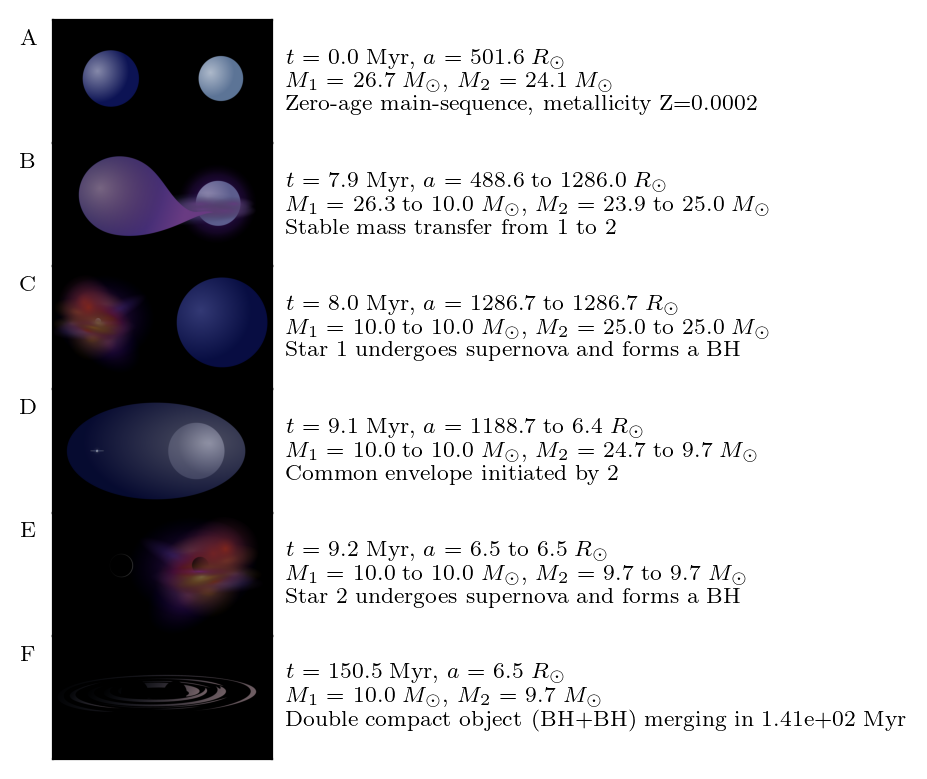

In [11]:
RawData = df_detailed_perfect
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
# print("Merges Hubble Time?:", df_dco_perfect['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [34]:
df_sanity_perfect = pd.read_csv(perfect_DataPath+'/sanity_checks.csv', header=0)
df_sanity_perfect = df_sanity_perfect.rename(columns=lambda x: x.strip())

df_sanity_perfect['SemiMajorAxis_Rsun'] = (df_sanity_perfect['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_perfect['Period1'] = (2 * np.pi / (df_sanity_perfect['Omega1'].values / u.yr)).to(u.day)
df_sanity_perfect['Period2'] = (2 * np.pi / (df_sanity_perfect['Omega2'].values / u.yr)).to(u.day)
df_sanity_perfect['Period_orb'] = (2 * np.pi / (df_sanity_perfect['Omega'].values / u.yr)).to(u.day)

df_sanity_perfect_short = df_sanity_perfect[columns_to_keep_sanity]

df_sanity_perfect.iloc[np.where(df_sanity_perfect['StellarType_2'] == 7)[0][-1]:]

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn,SemiMajorAxis_Rsun,Period1,Period2,Period_orb
8628,1919508,9.13146,0.000001,14,7,23.7485,23.7485,23.6535,23.6537,8.226050e-10,8.225870e-10,0.095003,9.482660e-02,5368.08,5367.96,5368.08,5367.96,5.377950e+03,5367.96,0.000000e+00,0,9.9509,0.000042,1.532400e-13,1.532400e-13,9.68458,0.918382,1.766530e-05,1.766530e-05,0.029963,0.029964,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,9.9509,0.000042,6.61160,0.000071,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000e-10,1.974190e+05,0.48684,21.995600,0.0,-0.0,0.0,0.0,0.0,0.0,inf,inf,inf,inf,0.0,-4.733780e-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.943040e-27,-1.065180e-09,-4.943040e-27,-1.075660e-09,-2.566050e-48,-3.430960e-16,4.943040e-27,1.054770e-09,1.451100e-71,1.000890e-17,-0.000000e+00,-0.000000e+00,-3.737700e-56,-2.236380e-10,6.443137,0.427524,0.427524,0.427524
8629,1919508,9.13146,0.002186,14,8,23.7484,23.7484,23.6536,23.7186,8.225870e-10,8.158360e-10,0.094805,2.984110e-02,5367.89,5323.91,5367.96,5323.91,1.691410e+04,5323.91,0.000000e+00,0,9.9509,0.000042,1.532400e-13,1.532400e-13,9.68448,0.918380,5.605100e-06,5.605100e-06,0.029964,0.030129,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,9.9509,0.000042,6.61160,0.000071,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000e-10,1.974190e+05,0.48684,21.995600,0.0,-0.0,0.0,0.0,0.0,0.0,inf,inf,inf,inf,0.0,-1.034830e-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.942570e-27,-1.065050e-09,-4.942920e-27,-9.103320e-08,-3.079270e-39,-5.213690e-08,4.942220e-27,-2.574890e-08,1.741090e-62,1.520770e-09,-0.000000e+00,0.000000e+00,-4.484570e-47,-1.070900e-01,6.478618,0.431062,0.431062,0.431062
8630,1919508,9.13364,0.000272,14,8,23.7484,23.7484,23.7186,23.7184,8.158360e-10,8.158500e-10,0.029840,2.999220e-02,5323.90,5324.00,5323.91,5324.00,5.297020e+03,5324.00,0.000000e+00,0,9.9509,0.000042,1.532400e-13,1.532400e-13,9.68446,0.925753,5.633390e-06,5.633390e-06,0.030129,0.030128,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,9.9509,0.000042,6.64508,0.000071,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000e-10,2.024680e+05,0.48684,22.046600,0.0,-0.0,0.0,0.0,0.0,0.0,inf,inf,inf,inf,0.0,-1.333940e-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.835280e-27,-1.075800e-09,-4.835320e-27,-1.047070e-09,-8.564010e-42,5.125840e-15,4.835240e-27,1.105010e-09,4.698370e-65,-1.509880e-16,-0.000000e+00,-0.000000e+00,-1.206850e-49,1.055000e-08,6.478553,0.431054,0.431054,0.431054
8631,1919508,9.13392,0.000267,14,8,23.7484,23.7484,23.7184,23.7184,8.158500e-10,8.158510e-10,0.029991,3.001140e-02,5323.99,5324.01,5324.00,5324.01,5.320450e+03,5324.01,0.000000e+00,0,9.9509,0.0

In [35]:
st_change_idx = np.where((df_sanity_perfect_short['StellarType_1'] != df_sanity_perfect_short['StellarType_1'].shift()) | (df_sanity_perfect_short['StellarType_2'] != df_sanity_perfect_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_perfect_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,26.70760,24.13840,4.800230,4.521210,0.000000e+00,13.53120,0.000000e+00,11.80580,0.000000e+00,2.467860,0.000000e+00,2.263780,501.637764,0,1,1,182.512739,182.512739,182.512739,1.673520e-02,1.341800e-02,867.6380,0.000,0.00000,5.169080e-11,3.846470e-11,5.169080e-11,3.846470e-11,0,0,0.000000e+00,0.000000e+00,2.237830e-12,1.512230e-12
1288,7.30215,26.37570,23.93700,11.701300,10.037000,0.000000e+00,7.98290,0.000000e+00,7.43831,0.000000e+00,0.814986,0.000000e+00,0.890561,506.800686,0,1,1,186.317897,186.317897,186.317897,9.620110e-02,6.423700e-02,858.5840,0.000,0.00000,-1.532980e-24,1.118090e-27,-1.532980e-24,1.118090e-27,0,0,0.000000e+00,0.000000e+00,-2.096420e-18,1.360590e-22
1289,7.30215,26.37560,23.93700,11.495300,10.037000,2.933610e-259,7.98290,0.000000e+00,7.43830,1.487190e-129,0.814986,0.000000e+00,0.890560,506.839392,0,2,1,186.339077,186.339077,186.339077,6.503310e-02,6.422960e-02,858.6130,0.000,0.00000,-8.294350e-18,1.281810e-31,-8.294350e-18,1.281810e-31,0,0,-inf,0.000000e+00,-9.667510e-12,1.559810e-26
2368,7.31306,26.37480,23.93640,35.714000,10.071500,9.053720e-138,8.14255,0.000000e+00,7.43176,2.698940e-68,0.825049,0.000000e+00,0.888525,506.196446,0,2,1,185.985707,185.985707,185.985707,6.208950e-01,6.479320e-02,858.0340,0.000,0.00000,2.091030e-27,5.154410e-31,2.091030e-27,5.154410e-31,0,0,7.315800e-77,0.000000e+00,6.042730e-17,6.595880e-26
2369,7.31306,26.37470,23.93640,35.712200,10.071500,8.956900e-138,8.14255,0.000000e+00,7.43173,2.684340e-68,0.825049,0.000000e+00,0.888522,506.198596,0,4,1,185.988721,185.988721,185.988721,6.208210e-01,6.479220e-02,858.0300,0.000,0.00000,-1.748460e-30,2.358360e-30,-1.748460e-30,2.358360e-30,0,0,-5.101510e-78,0.000000e+00,-5.050400e-20,3.017880e-25
4118,7.87954,26.30450,23.90580,189.173000,12.506800,5.393110e-39,9.95833,0.000000e+00,7.09298,3.560650e-18,1.022830,0.000000e+00,0.783048,488.602515,0,4,1,176.552354,176.552354,176.552354,1.644530e+01,1.051210e-01,840.5110,0.000,0.00000,3.234210e-30,1.225750e-28,3.234210e-30,1.225750e-28,0,0,9.834420e-26,0.000000e+00,5.777350e-14,3.221430e-22
4119,7.87960,9.95851,25.01890,1.022830,11.195800,0.000000e+00,6.45671,0.000000e+00,7.75750,0.000000e+00,0.192225,0.000000e+00,0.881202,1286.032062,0,7,1,903.275278,903.275278,903.275278,5.724570e-05,1.723150e-02,647.3260,-16.346,1.11305,-1.993810e-17,-2.776370e-11,-1.993810e-17,-2.776370e-11,0,0,0.000000e+00,0.000000e+00,-6.246050e-16,-1.122920e-05
4211,8.00123,9.95271,25.01090,0.933968,11.750900,0.000000e+00,6.81332,0.000000e+00,7.67636,0.000000e+00,0.000071,0.000000e+00,0.856557,1286.533087,0,7,1,903.979767,903.979767,903.979767,4.766610e-05,1.896170e-02,646.9950,0.000,0.00000,0.000000e+00,8.101520e-30,0.000000e+00,8.101520e-30,0,0,0.000000e+00,0.000000e+00,-1.598670e-27,6.444010e-24
4212,8.00123,9.95260,25.01080,0.933966,11.750900,0.000000e+00,6.81332,0.000000e+00,7.67630,0.000000e+00,0.000071,0.000000e+00,0.856553,1286.541688,0,8,1,903.994010,903.994010,903.994010,1.503450e-05,1.896110e-02,646.9890,0.000,0.00000,0.000000e+00,6.094340e-32,0.000000e+00,6.094340e-32,0,0,0.000000e+00,0.000000e+00,-8.074160e-17,4.847450e-26
4338,8.02915,9.95090,25.00910,1.067170,11.889200,0.000000e+00,7.34154,0.000000e+00,7.65776,0.000000e+00,0.000071,0.000000e+00,0.850905,1286.666407,0,8,1,904.164966,904.164966,904.164966,1.631250e-05,1.940520e-02,646.8970,0.000,0.00000,0.000000e+00,4.762580e-29,0.000000e+00,4.762580e-29,0,0,0.000000e+00,0.000000e+00,7.365150e-26,4.452440e-23


### Test the COMPAS output for comparison

In [42]:
pop_df = pd.read_csv('data_files/' + 'perfect_spin_df.csv') 
pop_df = pop_df.query('SEED == 1919508')
pop_df

,SEED,Mass@ZAMS(1),Mass@ZAMS(2),Metallicity@ZAMS(1),Omega(1),Omega(2),Eccentricity@ZAMS,SemiMajorAxis@ZAMS,CH_on_MS(1),CH_on_MS(2),Mass@DCO(1),Mass@DCO(2),SemiMajorAxis@DCO,Eccentricity@DCO,Stellar_Type(1),Stellar_Type(2),Merges_Hubble_Time,Time@DCO,Coalescence_Time,M_min@DCO,M_max@DCO,Ang_Momentum(SN)_Primary,Ang_Momentum(SN)_Secondary,Ang_Momentum(SN)_Both,MT_Donor_Hist(SN)_Primary,MT_Donor_Hist(SN)_Secondary,Mass(CP)_Primary,Mass(CP)_Secondary,Mass(CP)_Both,Mass(SN)_Primary,Mass(SN)_Secondary,Mass(SN)_Both,Mass_CO_Core@CO(SN)_Primary,Mass_CO_Core@CO(SN)_Secondary,Mass_CO_Core@CO(SN)_Both,Mass_Core@CO(SN)_Primary,Mass_Core@CO(SN)_Secondary,Mass_Core@CO(SN)_Both,Mass_Total@CO(SN)_Primary,Mass_Total@CO(SN)_Secondary,Mass_Total@CO(SN)_Both,Number_of_RLOF(SN)_Primary,Number_of_RLOF(SN)_Secondary,Number_of_RLOF(SN)_Both,Omega(SN)_Primary,Omega(SN)_Secondary,Omega(SN)_Both,Orbital_Period<SN_Primary,Orbital_Period<SN_Secondary,Orbital_Period<SN_Both,RLOF_Primary,RLOF_Secondary,RLOF_Both,Radius_Core@CO(SN)_Primary,Radius_Core@CO(SN)_Secondary,Radius_Core@CO(SN)_Both,Radius_Total@CO(SN)_Primary,Radius_Total@CO(SN)_Secondary,Radius_Total@CO(SN)_Both,SN_Orbit_Inclination_Angle_Primary,SN_Orbit_Inclination_Angle_Secondary,SN_Orbit_Inclination_Angle_Both,SN_Type(SN)_Primary,SN_Type(SN)_Secondary,SN_Type(SN)_Both,SemiMajorAxis<SN_Primary,SemiMajorAxis<SN_Secondary,SemiMajorAxis<SN_Both,Stellar_Type_Prev(SN)_Primary,Stellar_Type_Prev(SN)_Secondary,Stellar_Type_Prev(SN)_Both,Time@SN_Primary,Time@SN_Secondary,Time@SN_Both,Eccentricity<CE_Primary,Eccentricity<CE_Secondary,Eccentricity<CE_Both,Mass(1)<CE_Primary,Mass(1)<CE_Secondary,Mass(1)<CE_Both,Mass(2)<CE_Primary,Mass(2)<CE_Secondary,Mass(2)<CE_Both,SemiMajorAxis<CE_Primary,SemiMajorAxis<CE_Secondary,SemiMajorAxis<CE_Both,Stellar_Type(1)<CE_Primary,Stellar_Type(1)<CE_Secondary,Stellar_Type(1)<CE_Both,Stellar_Type(1)>CE_Primary,Stellar_Type(1)>CE_Secondary,Stellar_Type(1)>CE_Both,Stellar_Type(2)<CE_Primary,Stellar_Type(2)<CE_Secondary,Stellar_Type(2)<CE_Both,Stellar_Type(2)>CE_Primary,Stellar_Type(2)>CE_Secondary,Stellar_Type(2)>CE_Both,Time@CE_Primary,Time@CE_Secondary,Time@CE_Both,CE_Primary,CE_Secondary,CE_Both,BBH,BHNS,BNS,z_form,z_merger,a1,a2,a1_orb,a2_orb,fallback_1,fallback_2,iota1,iota2,chi_eff,chi_eff_orb
32228,1919508,26.707644,24.138389,0.000185,0.000168,0.000168,0.039411,2.336644,False,False,9.950902,9.682823,0.030207,0.0,14,14,True,9.160238,141.503913,9.682823,9.950902,0.000016,0.032869,NaN,[4],[4],25.009049,9.950902,NaN,9.950902,9.682823,NaN,7.344952,7.136522,NaN,7.344952,7.136522,NaN,9.950902,9.682823,NaN,1.0,1.0,NaN,3.37311,7377.117754,NaN,904.184488,0.430978,NaN,True,True,True,0.000071,0.000071,NaN,1.068247,1.059141,NaN,0.0,0.0,NaN,1.0,1.0,NaN,5.983602,0.030123,NaN,8.0,8.0,NaN,8.029295,9.160238,NaN,NaN,0.0,NaN,NaN,9.950902,NaN,NaN,24.727862,NaN,NaN,1188.683544,NaN,NaN,14.0,NaN,NaN,14.0,NaN,NaN,4.0,NaN,NaN,7.0,NaN,NaN,9.106671,NaN,False,True,False,True,False,False,9.895663,8.08011,0.000264,0.561608,0.000264,0.562053,1.0,1.0,0.0,0.0,0.277104,0.277323


In [44]:
m2 = pop_df["Mass_Total@CO(SN)_Secondary"].values * u.M_sun
r2 = pop_df["Radius_Total@CO(SN)_Secondary"].values * u.R_sun
m2_remnant = pop_df["Mass@DCO(2)"].values * u.M_sun
m2_core = pop_df["Mass_CO_Core@CO(SN)_Secondary"].values * u.M_sun
r2_core = pop_df["Radius_Core@CO(SN)_Secondary"].values * u.R_sun
period_orb2 = pop_df["Orbital_Period<SN_Secondary"].values * u.d
st2 = pop_df['Stellar_Type_Prev(SN)_Secondary']
omega_orb_2 = (2 * np.pi / period_orb2).to(1/u.yr)

j2 = pop_df['Ang_Momentum(SN)_Secondary'].values * u.Msun * u.AU**2 / u.yr
m2_shell = m2 - m2_core
I2 = (0.21 * m2_core * (r2_core**2) + 0.1 * m2_shell * (r2**2))
omega2 = (j2 / I2).to(1/u.yr)   

period_orb2.to(u.day), omega_orb_2.to(1/u.d), omega2.to(1/u.d)

(<Quantity [0.430978] d>,
 <Quantity [14.57890021] 1 / d>,
 <Quantity [14.56737022] 1 / d>)

In [46]:
2*np.pi/period_orb2.to(u.day)

<Quantity [14.57890021] 1 / d>

In [86]:
j_core = 0.21 * m2_core * (r2_core**2) * omega2
j_shell = 0.1 * m2_shell * (r2**2) * omega2

print((j_core + j_shell).to(u.Msun * u.AU**2 / u.yr))

fallback_fraction = np.maximum((m2_remnant - m2_core)/m2_shell, 0)
fallback_fraction = np.nan_to_num(fallback_fraction, nan=0.0, posinf=0.0, neginf=0.0) # For stars with no shell, fallback fraction becomes NaN or inf. If so, ignore the shell angular momentum.
fallback_fraction = np.minimum(fallback_fraction, 1.0) # Cap fallback fraction at 1.0

a = (c.c * (j_core + (fallback_fraction*j_shell))/ (c.G * (m2_remnant)**2)).to(u.dimensionless_unscaled)

a

[0.03286863] AU2 solMass / yr


<Quantity [0.56160826]>

In [47]:
j_core = 0.21 * m2_core * (r2_core**2) * omega_orb_2
j_shell = 0.1 * m2_shell * (r2**2) * omega_orb_2

print((j_core + j_shell).to(u.Msun * u.AU**2 / u.yr))


fallback_fraction = np.maximum((m2_remnant - m2_core)/m2_shell, 0)
fallback_fraction = np.nan_to_num(fallback_fraction, nan=0.0, posinf=0.0, neginf=0.0) # For stars with no shell, fallback fraction becomes NaN or inf. If so, ignore the shell angular momentum.
fallback_fraction = np.minimum(fallback_fraction, 1.0) # Cap fallback fraction at 1.0

a = (c.c * (j_core + (fallback_fraction*j_shell))/ (c.G * (m2_remnant)**2)).to(u.dimensionless_unscaled)
a

[0.03289464] AU2 solMass / yr


<Quantity [0.56205277]>

In [14]:
st_labels[4], st_labels[7], st_labels[8]

('CHeB', 'HeMS', 'HeHG')

# CHE Binary

In [13]:
tides_DataPath = 'sim_data/che_realistic'
# notides_DataPath = 'sim_data/che_z77'
notides_DataPath = 'sim_data/che_notides'
perfect_DataPath = 'sim_data/che_perfect'

df_detailed_tides = pd.read_csv(tides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0, low_memory=False)
df_detailed_tides = df_detailed_tides.rename(columns=lambda x: x.strip())

df_detailed_notides = pd.read_csv(notides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_notides = df_detailed_notides.rename(columns=lambda x: x.strip())

df_detailed_perfect = pd.read_csv(perfect_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0, low_memory=False)
df_detailed_perfect = df_detailed_perfect.rename(columns=lambda x: x.strip())


df_dco_tides = pd.read_csv(tides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_tides = df_dco_tides.rename(columns=lambda x: x.strip())

df_dco_notides = pd.read_csv(notides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_notides = df_dco_notides.rename(columns=lambda x: x.strip())

df_dco_perfect = pd.read_csv(perfect_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_perfect = df_dco_perfect.rename(columns=lambda x: x.strip())

### Realistic

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000064   Zero-age main-sequence, metallicity Z=0.0003   46.620    16     46.620    16     15.966  0.000
  6.443650   Star 1: CHE->HeMS                 44.673     7     44.673     7     17.133  0.000
  6.443650   Star 2: CHE->HeMS                 44.673     7     44.673     7     17.133  0.000
  6.722919   Star 1: HeMS->HeHG                44.265     8     44.265     8     17.476  0.000
  6.722919   Star 2: HeMS->HeHG                44.265     8     44.265     8     17.476  0.000
  6.722919   Star 1 undergoes supernova and forms a BH   42.049    14     42.049    14     18.462  0.051
  6.722919   Star 2 undergoes supernova and forms a BH   42.049    14     42.049    14     18.462  0.051
122.979542   Double compact object (BH+BH) merging in 1.16e+02 Myr   42.049    14     42.049    14     18.462  0.051
Merges Hubble Time?: [ True]


(<Figure size 900x480 with 4 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x16b985d50>])

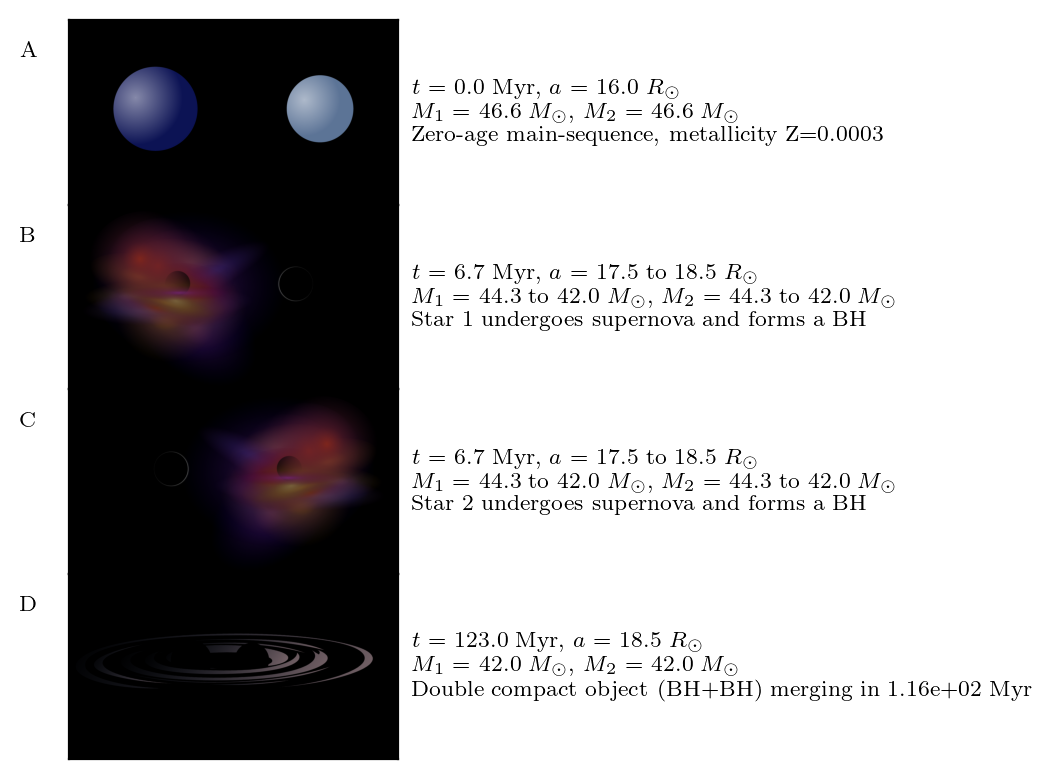

In [27]:
RawData = df_detailed_tides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [117]:
df_sanity_tides = pd.read_csv(tides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_tides = df_sanity_tides.rename(columns=lambda x: x.strip())

df_sanity_tides['SemiMajorAxis_Rsun'] = (df_sanity_tides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_tides['Period1'] = (2 * np.pi / (df_sanity_tides['Omega1'].values / u.yr)).to(u.day)
df_sanity_tides['Period2'] = (2 * np.pi / (df_sanity_tides['Omega2'].values / u.yr)).to(u.day)
df_sanity_tides['Period_orb'] = (2 * np.pi / (df_sanity_tides['Omega'].values / u.yr)).to(u.day)

df_sanity_tides_short = df_sanity_tides[columns_to_keep_sanity]

df_sanity_tides.iloc[np.where(df_sanity_tides['StellarType_2'] == 7)]

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn,SemiMajorAxis_Rsun,Period1,Period2,Period_orb
103,1,6.44580,0.013935,7,7,396.539,396.539,374.024,374.024,11.2574,11.2574,11.2574,11.2574,2640.00,2640.00,21530.0,21530.0,21530.0,21530.0,0.0,0.0,44.6398,2.32723,0.000523,0.000523,44.6398,2.32723,0.000523,0.000523,0.079671,0.079671,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,0,0,0,0,44.6398,2.327230,44.6398,2.327230,0,0,0,0,0,0,0,0,1601810.0,1601810.0,23.3202,23.3202,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0,0,inf,inf,inf,inf,-0.015634,-0.015634,0,0,0,0,0,0,0,0,0,0,6.617120e-08,-6.617120e-08,-0.000096,-0.000096,-0.000080,-0.000080,-0.000066,-0.000066,0.000002,0.000002,0.0,0.0,-10.46640,-10.46640,17.131870,0.106592,0.106592,0.869293
104,1,6.45974,0.007521,7,7,396.466,396.466,373.980,374.008,11.2428,11.2290,11.2428,11.2290,2638.35,2637.77,21431.7,21405.3,21431.7,21405.3,0.0,0.0,44.6311,2.33127,0.000525,0.000525,44.6311,2.33127,0.000525,0.000525,0.079699,0.079711,3.744100e-05,3.744100e-05,-5.351200e-02,-5.351200e-02,-4.465650e-02,-4.465650e-02,-3.677890e-02,-3.677890e-02,3.744100e-05,3.744100e-05,-5.351200e-02,-5.351200e-02,-4.465650e-02,-4.465650e-02,-3.677890e-02,-3.677890e-02,0,0,0,0,0,0,0,0,43.5676,2.214730,43.5676,2.214730,0,0,0,0,0,0,0,0,1637400.0,1637400.0,23.4284,23.4284,1.312120e-03,1.312120e-03,-5.868410e+03,-5.868410e+03,0,0,6.074090e-07,inf,4.495860e-09,4.495860e-09,-0.008692,-0.008692,0,0,0,0,0,0,0,0,0,0,6.650160e-08,-6.650160e-08,-0.000095,-0.000095,-0.000079,-0.000079,-0.000065,-0.000065,0.000002,0.000002,0.0,0.0,-10.42330,-10.42330,17.140428,0.107213,0.107213,0.870028
105,1,6.46726,0.007532,7,7,396.392,396.392,373.964,373.991,11.2141,11.2003,11.2141,11.2003,2636.10,2635.51,21343.7,21317.4,21343.7,21317.4,0.0,0.0,44.6223,2.33333,0.000525,0.000525,44.6223,2.33333,0.000525,0.000525,0.079739,0.079751,2.943920e-05,2.943920e-05,-4.168770e-02,-4.168770e-02,-3.476630e-02,-3.476630e-02,-2.861190e-02,-2.861190e-02,2.943920e-05,2.943920e-05,-4.168770e-02,-4.168770e-02,-3.476630e-02,-3.476630e-02,-2.861190e-02,-2.861190e-02,0,0,0,0,0,0,0,0,42.9959,2.153730,42.9959,2.153730,0,0,0,0,0,0,0,0,1656390.0,1656390.0,23.4857,23.4857,1.023080e-03,1.023080e-03,-4.566040e+03,-4.566040e+03,0,0,7.794070e-07,inf,5.773270e-09,5.773270e-09,-0.008842,-0.008842,0,0,0,0,0,0,0,0,0,0,6.656400e-08,-6.656400e-08,-0.000094,-0.000094,-0.000079,-0.000079,-0.000065,-0.000065,0.000002,0.000002,0.0,0.0,-10.32410,-10.32410,17.149072,0.107655,0.107655,0.870774
106,1,6.47479,0.007537,7,7,396.316,3

In [119]:
st_change_idx = np.where((df_sanity_tides_short['StellarType_1'] != df_sanity_tides_short['StellarType_1'].shift()) | (df_sanity_tides_short['StellarType_2'] != df_sanity_tides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_tides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,46.6000,46.6000,6.785540,6.785540,0,28.6870,0,28.6870,0,3.889090,0,3.889090,15.955386,0.000000,16,16,7.646949e-01,7.646949e-01,0.764695,13.9261,13.9261,384.987,0,0,4.937770e-21,4.937770e-21,4.937770e-21,4.937770e-21,0,0,0,0,5.063830e-22,5.063830e-22
102,6.44580,44.6555,44.6555,6.785540,6.785540,0,16.2494,0,16.2494,0,1.261170,0,1.261170,17.121054,0.000000,16,16,9.043859e-01,9.043859e-01,0.868316,11.2838,11.2838,374.102,0,0,4.978140e-12,4.978140e-12,4.978140e-12,4.978140e-12,0,0,0,0,5.657960e-09,5.657960e-09
103,6.44580,44.6398,44.6398,2.327230,2.327230,0,44.6398,0,44.6398,0,2.327230,0,2.327230,17.131870,0.000000,7,7,1.065924e-01,1.065924e-01,0.869293,11.2574,11.2574,374.024,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-7.987680e-05,-7.987680e-05
145,6.72513,44.2480,44.2480,2.314880,2.314880,0,36.4072,0,36.4072,0,0.000072,0,0.000072,17.463600,0.000000,7,7,1.143675e-01,1.143675e-01,0.898617,10.2899,10.2899,372.666,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-6.305450e-05,-6.305450e-05
146,6.72513,42.0414,42.0414,0.000178,0.000178,0,42.0414,0,42.0414,0,0.000178,0,0.000178,18.448684,0.053173,14,14,2.581524e-09,2.581524e-09,1.000987,10.2733,10.2733,354.240,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-7.251500e-01,-7.251500e-01


In [112]:
pop_df = pd.read_csv('data_files/' + 'realistic_spin_df.csv') 
pop_df = pop_df.query('SEED == 9976')
pop_df

,SEED,Mass@ZAMS(1),Mass@ZAMS(2),Metallicity@ZAMS(1),Omega(1),Omega(2),Eccentricity@ZAMS,SemiMajorAxis@ZAMS,CH_on_MS(1),CH_on_MS(2),Mass@DCO(1),Mass@DCO(2),SemiMajorAxis@DCO,Eccentricity@DCO,Stellar_Type(1),Stellar_Type(2),Merges_Hubble_Time,Time@DCO,Coalescence_Time,M_min@DCO,M_max@DCO,Ang_Momentum(SN)_Primary,Ang_Momentum(SN)_Secondary,Ang_Momentum(SN)_Both,MT_Donor_Hist(SN)_Primary,MT_Donor_Hist(SN)_Secondary,Mass(CP)_Primary,Mass(CP)_Secondary,Mass(CP)_Both,Mass(SN)_Primary,Mass(SN)_Secondary,Mass(SN)_Both,Mass_CO_Core@CO(SN)_Primary,Mass_CO_Core@CO(SN)_Secondary,Mass_CO_Core@CO(SN)_Both,Mass_Core@CO(SN)_Primary,Mass_Core@CO(SN)_Secondary,Mass_Core@CO(SN)_Both,Mass_Total@CO(SN)_Primary,Mass_Total@CO(SN)_Secondary,Mass_Total@CO(SN)_Both,Number_of_RLOF(SN)_Primary,Number_of_RLOF(SN)_Secondary,Number_of_RLOF(SN)_Both,Omega(SN)_Primary,Omega(SN)_Secondary,Omega(SN)_Both,Orbital_Period<SN_Primary,Orbital_Period<SN_Secondary,Orbital_Period<SN_Both,RLOF_Primary,RLOF_Secondary,RLOF_Both,Radius_Core@CO(SN)_Primary,Radius_Core@CO(SN)_Secondary,Radius_Core@CO(SN)_Both,Radius_Total@CO(SN)_Primary,Radius_Total@CO(SN)_Secondary,Radius_Total@CO(SN)_Both,SN_Orbit_Inclination_Angle_Primary,SN_Orbit_Inclination_Angle_Secondary,SN_Orbit_Inclination_Angle_Both,SN_Type(SN)_Primary,SN_Type(SN)_Secondary,SN_Type(SN)_Both,SemiMajorAxis<SN_Primary,SemiMajorAxis<SN_Secondary,SemiMajorAxis<SN_Both,Stellar_Type_Prev(SN)_Primary,Stellar_Type_Prev(SN)_Secondary,Stellar_Type_Prev(SN)_Both,Time@SN_Primary,Time@SN_Secondary,Time@SN_Both,Eccentricity<CE_Primary,Eccentricity<CE_Secondary,Eccentricity<CE_Both,Mass(1)<CE_Primary,Mass(1)<CE_Secondary,Mass(1)<CE_Both,Mass(2)<CE_Primary,Mass(2)<CE_Secondary,Mass(2)<CE_Both,SemiMajorAxis<CE_Primary,SemiMajorAxis<CE_Secondary,SemiMajorAxis<CE_Both,Stellar_Type(1)<CE_Primary,Stellar_Type(1)<CE_Secondary,Stellar_Type(1)<CE_Both,Stellar_Type(1)>CE_Primary,Stellar_Type(1)>CE_Secondary,Stellar_Type(1)>CE_Both,Stellar_Type(2)<CE_Primary,Stellar_Type(2)<CE_Secondary,Stellar_Type(2)<CE_Both,Stellar_Type(2)>CE_Primary,Stellar_Type(2)>CE_Secondary,Stellar_Type(2)>CE_Both,Time@CE_Primary,Time@CE_Secondary,Time@CE_Both,CE_Primary,CE_Secondary,CE_Both,BBH,BHNS,BNS,z_form,z_merger,a1,a2,a1_orb,a2_orb,fallback_1,fallback_2,iota1,iota2,chi_eff,chi_eff_orb
6054,9976,46.620192,46.620192,0.000312,3188.430044,3188.430044,0.0,0.074247,True,True,42.04908,42.04908,0.094365,0.051301,14,14,True,6.722919,169.880448,42.04908,42.04908,1.163417,NaN,1.163417,NaN,NaN,42.04908,NaN,42.04908,42.04908,NaN,42.04908,36.422029,NaN,36.422029,36.422029,NaN,36.422029,44.264638,NaN,44.264638,0.0,NaN,0.0,3188.430044,NaN,3188.430044,1.049976,NaN,1.092878,True,True,True,0.000071,NaN,0.000071,2.28753,NaN,2.28753,0.0,NaN,0.0,8.0,NaN,8.0,0.089347,NaN,0.091765,8.0,NaN,8.0,6.722919,NaN,6.722919,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,True,False,False,8.910069,7.236374,0.674161,0.674161,0.126108,0.121157,0.717497,0.717497,0.0,0.0,0.674161,0.123632


In [113]:
m2 = pop_df["Mass_Total@CO(SN)_Both"].values * u.M_sun
r2 = pop_df["Radius_Total@CO(SN)_Both"].values * u.R_sun
m2_remnant = pop_df["Mass@DCO(2)"].values * u.M_sun
m2_core = pop_df["Mass_CO_Core@CO(SN)_Both"].values * u.M_sun
r2_core = pop_df["Radius_Core@CO(SN)_Both"].values * u.R_sun
period_orb2 = pop_df["Orbital_Period<SN_Both"].values * u.d
st2 = pop_df['Stellar_Type_Prev(SN)_Both']
omega_orb_2 = (2 * np.pi / period_orb2).to(1/u.yr)

j2 = pop_df['Ang_Momentum(SN)_Both'].values * u.Msun * u.AU**2 / u.yr
m2_shell = m2 - m2_core
I2 = (0.21 * m2_core * (r2_core**2) + 0.1 * m2_shell * (r2**2))
omega2 = (j2 / I2).to(1/u.yr)   


(2 * np.pi / omega2).to(u.d), (2 * np.pi / omega_orb_2).to(u.d)

(<Quantity [0.17507416] d>, <Quantity [1.09287789] d>)

In [90]:
j_core = 0.21 * m2_core * (r2_core**2) * omega2
j_shell = 0.1 * m2_shell * (r2**2) * omega2

print((j_core + j_shell).to(u.Msun * u.AU**2 / u.yr))

fallback_fraction = np.maximum((m2_remnant - m2_core)/m2_shell, 0)
fallback_fraction = np.nan_to_num(fallback_fraction, nan=0.0, posinf=0.0, neginf=0.0) # For stars with no shell, fallback fraction becomes NaN or inf. If so, ignore the shell angular momentum.
fallback_fraction = np.minimum(fallback_fraction, 1.0) # Cap fallback fraction at 1.0

a = (c.c * (j_core + (fallback_fraction*j_shell))/ (c.G * (m2_remnant)**2)).to(u.dimensionless_unscaled)

a

[1.16341659] AU2 solMass / yr


<Quantity [0.75630766]>

In [92]:
j_core = 0.21 * m2_core * (r2_core**2) * omega_orb_2 
j_shell = 0.1 * m2_shell * (r2**2) * omega_orb_2

print((j_core + j_shell).to(u.Msun * u.AU**2 / u.yr))


fallback_fraction = np.maximum((m2_remnant - m2_core)/m2_shell, 0)
fallback_fraction = np.nan_to_num(fallback_fraction, nan=0.0, posinf=0.0, neginf=0.0) # For stars with no shell, fallback fraction becomes NaN or inf. If so, ignore the shell angular momentum.
fallback_fraction = np.minimum(fallback_fraction, 1.0) # Cap fallback fraction at 1.0

a = (c.c * (j_core + (fallback_fraction*j_shell))/ (c.G * (m2_remnant)**2)).to(u.dimensionless_unscaled)
a

[0.18637415] AU2 solMass / yr


<Quantity [0.12115711]>

### No Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000064   Zero-age main-sequence, metallicity Z=0.0003   46.620    16     46.620    16     15.966  0.000
  6.443650   Star 1: CHE->HeMS                 44.673     7     44.673     7     17.029  0.000
  6.443650   Star 2: CHE->HeMS                 44.673     7     44.673     7     17.029  0.000
  6.722919   Star 1: HeMS->HeHG                44.265     8     44.265     8     17.316  0.000
  6.722919   Star 2: HeMS->HeHG                44.265     8     44.265     8     17.316  0.000
  6.722919   Star 1 undergoes supernova and forms a BH   42.049    14     42.049    14     18.294  0.051
  6.722919   Star 2 undergoes supernova and forms a BH   42.049    14     42.049    14     18.294  0.051
118.802999   Double compact object (BH+BH) merging in 1.12e+02 Myr   42.049    14     42.049    14     18.294  0.051
Merges Hubble Time?: [ True]


(<Figure size 900x480 with 4 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x16bcda590>])

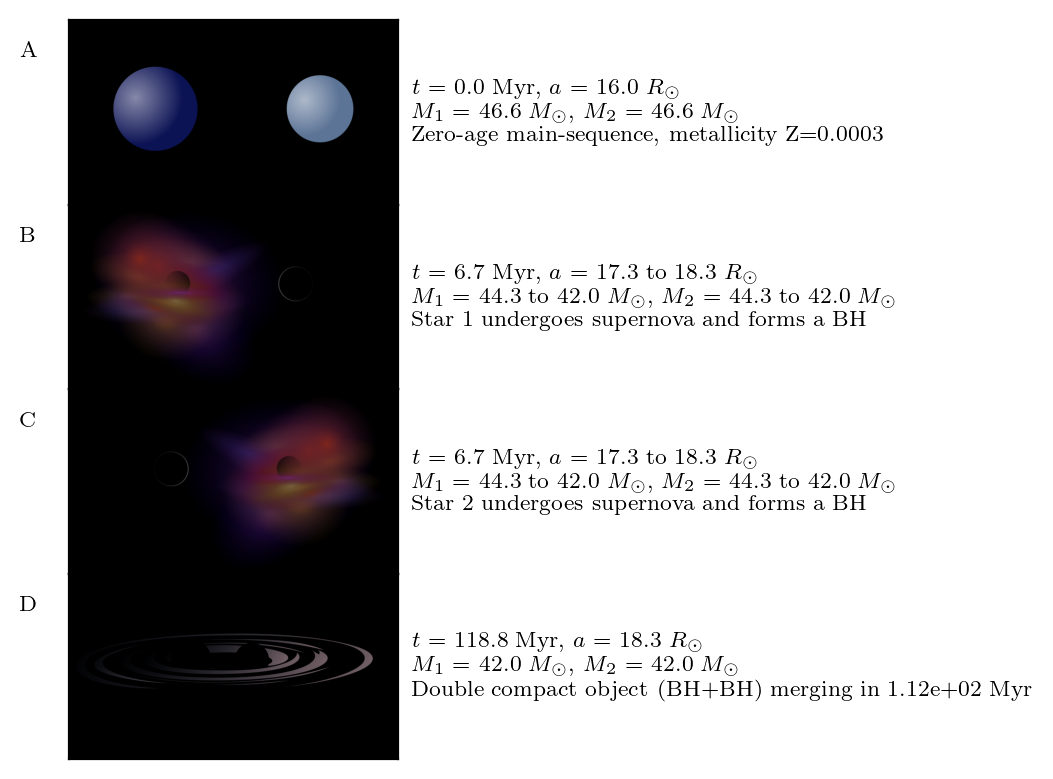

In [14]:
RawData = df_detailed_notides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_notides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [15]:
df_sanity_notides = pd.read_csv(notides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_notides = df_sanity_notides.rename(columns=lambda x: x.strip())

df_sanity_notides['SemiMajorAxis_Rsun'] = (df_sanity_notides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_notides['Period1'] = (2 * np.pi / (df_sanity_notides['Omega1'].values / u.yr)).to(u.day)
df_sanity_notides['Period2'] = (2 * np.pi / (df_sanity_notides['Omega2'].values / u.yr)).to(u.day)
df_sanity_notides['Period_orb'] = (2 * np.pi / (df_sanity_notides['Omega'].values / u.yr)).to(u.day)

df_sanity_notides_short = df_sanity_notides[columns_to_keep_sanity]
df_sanity_notides

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn,SemiMajorAxis_Rsun,Period1,Period2,Period_orb
0,9976,0.000000,0.000064,16,16,413.221,413.221,385.359,385.359,13.9306,13.9306,13.9306,13.9306,2998.90,2998.90,2.998890e+03,2.998900e+03,2.998890e+03,2.998900e+03,0.000000,0.000000,46.6202,6.787670,4.645240e-03,4.645240e-03,46.6202,6.787670,4.645240e-03,4.645240e-03,0.074247,0.074247,6.994450e-05,6.994450e-05,-6.994430e-05,-6.994430e-05,4.951580e-21,4.951580e-21,6.994470e-05,6.994470e-05,6.994450e-05,6.994450e-05,-6.994430e-05,-6.994430e-05,4.951580e-21,4.951580e-21,6.994470e-05,6.994470e-05,0,0,0,0,0,0,0,0,28.7038,3.890410,28.7038,3.890410,0,0,0,0,0,0,0,0,2.947940e+05,2.947940e+05,8.943740,8.943740,-4.593990e-20,-4.593990e-20,2.566480e-14,2.566480e-14,0,0,1.616180e+10,inf,1.168490e+09,1.168490e+09,-0.000009,-0.000009,0,0,0,0,0,0,0,0,0,0,7.181470e-06,7.181470e-06,-0.000007,-0.000007,5.083980e-22,5.083980e-22,0.000007,0.000007,-4.716830e-21,-4.716830e-21,-0.000000e+00,-0.000000e+00,2.635110e-15,2.635110e-15,15.965535,7.652584e-01,7.652584e-01,0.765258
1,9976,0.000064,0.063587,16,16,413.144,413.144,385.320,385.304,13.9122,13.9200,13.9122,13.9200,2996.85,2997.22,2.995530e+03,2.997220e+03,2.995530e+03,2.997220e+03,0.000000,0.000000,46.6110,6.787670,4.644320e-03,4.644320e-03,46.6110,6.787670,4.644320e-03,4.644320e-03,0.074276,0.074270,6.974070e-05,6.974070e-05,-6.957720e-05,-6.957720e-05,4.957440e-13,4.957440e-13,6.990450e-05,6.990450e-05,6.974070e-05,6.974070e-05,-6.957720e-05,-6.957720e-05,4.957440e-13,4.957440e-13,6.990450e-05,6.990450e-05,0,0,0,0,0,0,0,0,28.6960,3.889780,28.6960,3.889780,0,0,0,0,0,0,0,0,2.946750e+05,2.946750e+05,8.942840,8.942840,-4.589160e-12,-4.589160e-12,2.563030e-06,2.563030e-06,0,0,1.618510e+02,inf,1.169260e+01,1.169260e+01,-0.009222,-0.009222,0,0,0,0,0,0,0,0,0,0,7.166290e-06,7.166290e-06,-0.000007,-0.000007,5.094080e-14,5.094080e-14,0.000007,0.000007,-4.715650e-13,-4.715650e-13,-0.000000e+00,-0.000000e+00,2.633670e-07,2.633670e-07,15.970460,7.656873e-01,7.656873e-01,0.765687
2,9976,0.063651,0.063597,16,16,413.067,413.067,385.264,385.249,13.9015,13.9094,13.9015,13.9094,2995.15,2995.52,2.993820e+03,2.995520e+03,2.993820e+03,2.995520e+03,0.000000,0.000000,46.6016,6.787670,4.643390e-03,4.643390e-03,46.6016,6.787670,4.643390e-03,4.643390e-03,0.074299,0.074293,6.586430e-05,6.586430e-05,-6.570820e-05,-6.570820e-05,4.819220e-13,4.819220e-13,6.602070e-05,6.602070e-05,6.586430e-05,6.586430e-05,-6.570820e-05,-6.570820e-05,4.819220e-13,4.819220e-13,6.602070e-05,6.602070e-05,0,0,0,0,0,0,0,0,28.5735,3.863340,28.5735,3.863340,0,0,0,0,0,0,0,0,2.962680e+05,2.962680e+05,8.954900,8.954900,-4.453130e-12,-4.453130e-12,2.486420e-06,2.486420e-06,0,0,

In [16]:
st_change_idx = np.where((df_sanity_notides_short['StellarType_1'] != df_sanity_notides_short['StellarType_1'].shift()) | (df_sanity_notides_short['StellarType_2'] != df_sanity_notides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_notides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,46.6202,46.6202,6.787670,6.787670,0,28.7038,0,28.7038,0,3.890410,0,3.890410,15.965535,0.000000,16,16,7.652584e-01,7.652584e-01,0.765258,13.9306,13.9306,385.359,0,0,4.951580e-21,4.951580e-21,4.951580e-21,4.951580e-21,0,0,0,0,5.083980e-22,5.083980e-22
102,6.44365,44.6728,44.6728,6.787670,6.787670,0,16.2579,0,16.2579,0,1.261570,0,1.261570,17.028762,0.000000,16,16,8.611382e-01,8.611382e-01,0.861138,11.8624,11.8624,373.310,0,0,5.797000e-28,5.797000e-28,5.797000e-28,5.797000e-28,0,0,0,0,6.596670e-25,6.596670e-25
103,6.44365,44.6572,44.6572,2.327780,2.327780,0,44.6572,0,44.6572,0,2.327780,0,2.327780,17.039793,0.000000,7,7,1.014797e-01,1.014797e-01,0.862128,11.8347,11.8347,373.235,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-9.257060e-05,-9.257060e-05
145,6.72292,44.2648,44.2648,2.315410,2.315410,0,36.4221,0,36.4221,0,0.000072,0,0.000072,17.316346,0.000000,7,7,1.055583e-01,1.055583e-01,0.887106,11.1579,11.1579,371.303,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-8.019000e-05,-8.019000e-05
146,6.72292,42.0491,42.0491,0.000178,0.000178,0,42.0491,0,42.0491,0,0.000178,0,0.000178,18.293517,0.051302,14,14,2.382005e-09,2.382005e-09,0.988297,11.1400,11.1400,352.878,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-8.995430e-01,-8.995430e-01


In [17]:
pop_df = pd.read_csv('data_files/' + 'notides_spin_df.csv') 
pop_df = pop_df.query('SEED == 9976')
pop_df

,SEED,Mass@ZAMS(1),Mass@ZAMS(2),Metallicity@ZAMS(1),Omega(1),Omega(2),Eccentricity@ZAMS,SemiMajorAxis@ZAMS,CH_on_MS(1),CH_on_MS(2),Mass@DCO(1),Mass@DCO(2),SemiMajorAxis@DCO,Eccentricity@DCO,Stellar_Type(1),Stellar_Type(2),Merges_Hubble_Time,Time@DCO,Coalescence_Time,M_min@DCO,M_max@DCO,Ang_Momentum(SN)_Primary,Ang_Momentum(SN)_Secondary,Ang_Momentum(SN)_Both,MT_Donor_Hist(SN)_Primary,MT_Donor_Hist(SN)_Secondary,Mass(CP)_Primary,Mass(CP)_Secondary,Mass(CP)_Both,Mass(SN)_Primary,Mass(SN)_Secondary,Mass(SN)_Both,Mass_CO_Core@CO(SN)_Primary,Mass_CO_Core@CO(SN)_Secondary,Mass_CO_Core@CO(SN)_Both,Mass_Core@CO(SN)_Primary,Mass_Core@CO(SN)_Secondary,Mass_Core@CO(SN)_Both,Mass_Total@CO(SN)_Primary,Mass_Total@CO(SN)_Secondary,Mass_Total@CO(SN)_Both,Number_of_RLOF(SN)_Primary,Number_of_RLOF(SN)_Secondary,Number_of_RLOF(SN)_Both,Omega(SN)_Primary,Omega(SN)_Secondary,Omega(SN)_Both,Orbital_Period<SN_Primary,Orbital_Period<SN_Secondary,Orbital_Period<SN_Both,RLOF_Primary,RLOF_Secondary,RLOF_Both,Radius_Core@CO(SN)_Primary,Radius_Core@CO(SN)_Secondary,Radius_Core@CO(SN)_Both,Radius_Total@CO(SN)_Primary,Radius_Total@CO(SN)_Secondary,Radius_Total@CO(SN)_Both,SN_Orbit_Inclination_Angle_Primary,SN_Orbit_Inclination_Angle_Secondary,SN_Orbit_Inclination_Angle_Both,SN_Type(SN)_Primary,SN_Type(SN)_Secondary,SN_Type(SN)_Both,SemiMajorAxis<SN_Primary,SemiMajorAxis<SN_Secondary,SemiMajorAxis<SN_Both,Stellar_Type_Prev(SN)_Primary,Stellar_Type_Prev(SN)_Secondary,Stellar_Type_Prev(SN)_Both,Time@SN_Primary,Time@SN_Secondary,Time@SN_Both,Eccentricity<CE_Primary,Eccentricity<CE_Secondary,Eccentricity<CE_Both,Mass(1)<CE_Primary,Mass(1)<CE_Secondary,Mass(1)<CE_Both,Mass(2)<CE_Primary,Mass(2)<CE_Secondary,Mass(2)<CE_Both,SemiMajorAxis<CE_Primary,SemiMajorAxis<CE_Secondary,SemiMajorAxis<CE_Both,Stellar_Type(1)<CE_Primary,Stellar_Type(1)<CE_Secondary,Stellar_Type(1)<CE_Both,Stellar_Type(1)>CE_Primary,Stellar_Type(1)>CE_Secondary,Stellar_Type(1)>CE_Both,Stellar_Type(2)<CE_Primary,Stellar_Type(2)<CE_Secondary,Stellar_Type(2)<CE_Both,Stellar_Type(2)>CE_Primary,Stellar_Type(2)>CE_Secondary,Stellar_Type(2)>CE_Both,Time@CE_Primary,Time@CE_Secondary,Time@CE_Both,CE_Primary,CE_Secondary,CE_Both,BBH,BHNS,BNS,z_form,z_merger,a1,a2,a1_orb,a2_orb,fallback_1,fallback_2,iota1,iota2,chi_eff,chi_eff_orb
898,9976,46.620192,46.620192,0.000312,30529.766497,30529.766497,0.0,0.074247,True,True,42.049135,42.049135,0.085073,0.051302,14,14,True,6.722919,112.219996,42.049135,42.049135,11.139958,NaN,11.139958,NaN,NaN,42.049135,NaN,42.049135,42.049135,NaN,42.049135,36.422135,NaN,36.422135,36.422135,NaN,36.422135,44.264758,NaN,44.264758,0.0,NaN,0.0,30529.766497,NaN,30529.766497,0.898775,NaN,0.9355,True,True,True,0.000071,NaN,0.000071,2.287533,NaN,2.287533,0.0,NaN,0.0,8.0,NaN,8.0,0.080549,NaN,0.082729,8.0,NaN,8.0,6.722919,NaN,6.722919,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,True,False,False,8.910069,7.701707,0.674162,0.674162,0.147321,0.141538,0.71749,0.71749,0.0,0.0,0.674162,0.14443


In [18]:
m2 = pop_df["Mass_Total@CO(SN)_Both"].values * u.M_sun
r2 = pop_df["Radius_Total@CO(SN)_Both"].values * u.R_sun
m2_remnant = pop_df["Mass@DCO(2)"].values * u.M_sun
m2_core = pop_df["Mass_CO_Core@CO(SN)_Both"].values * u.M_sun
r2_core = pop_df["Radius_Core@CO(SN)_Both"].values * u.R_sun
period_orb2 = pop_df["Orbital_Period<SN_Both"].values * u.d
st2 = pop_df['Stellar_Type_Prev(SN)_Both']
omega_orb_2 = (2 * np.pi / period_orb2).to(1/u.yr)

j2 = pop_df['Ang_Momentum(SN)_Both'].values * u.Msun * u.AU**2 / u.yr
m2_shell = m2 - m2_core
# I2 = (0.21 * m2_core * (r2_core**2) + 0.1 * m2_shell * (r2**2))
# I2 = (0.1 * (m2) * (r2) * (r2))
I2 = 0.1 * m2 * r2**2
gb_mask = (st2==8)
I2[gb_mask] = (0.21 * m2_core * (r2_core**2) + 0.1 * m2_shell * (r2**2))

omega2 = (j2 / I2).to(1/u.yr)   


(2*np.pi/omega2).to(u.d), (2*np.pi/omega_orb_2).to(u.d)


(<Quantity [0.0182842] d>, <Quantity [0.93550035] d>)

In [19]:
j_core = 0.21 * m2_core * (r2_core**2) * (2 * np.pi / period_orb2).to(1/u.yr)
j_shell = 0.1 * m2_shell * (r2**2) * (2 * np.pi / period_orb2).to(1/u.yr)

print((j_core + j_shell).to(u.Msun * u.AU**2 / u.yr))


fallback_fraction = np.maximum((m2_remnant - m2_core)/m2_shell, 0)
fallback_fraction = np.nan_to_num(fallback_fraction, nan=0.0, posinf=0.0, neginf=0.0) # For stars with no shell, fallback fraction becomes NaN or inf. If so, ignore the shell angular momentum.
fallback_fraction = np.minimum(fallback_fraction, 1.0) # Cap fallback fraction at 1.0

a = (c.c * (j_core + (fallback_fraction*j_shell))/ (c.G * (m2_remnant)**2)).to(u.dimensionless_unscaled)
a

[0.21772859] AU2 solMass / yr


<Quantity [0.14153793]>

In [20]:
df_detailed_notides[np.where(df_detailed_notides['Stellar_Type(1)'] == 8)[0][0]:]

,SEED,dT,Time,Unbound,SemiMajorAxis,Eccentricity,Mass@ZAMS(1),Mass@ZAMS(2),Mass_0(1),Mass_0(2),Mass(1),Mass(2),Mass_Env(1),Mass_Env(2),Mass_Core(1),Mass_Core(2),Mass_He_Core(1),Mass_He_Core(2),Mass_CO_Core(1),Mass_CO_Core(2),Radius(1),Radius(2),RocheLobe(1),RocheLobe(2),Omega(1),Omega(2),Omega_Break(1),Omega_Break(2),Stellar_Type@ZAMS(1),Stellar_Type@ZAMS(2),Stellar_Type(1),Stellar_Type(2),Age(1),Age(2),Luminosity(1),Luminosity(2),Teff(1),Teff(2),Ang_Momentum(1),Ang_Momentum(2),Tau_Dynamical(1),Tau_Dynamical(2),Tau_Thermal(1),Tau_Thermal(2),Zeta_Soberman(1),Zeta_Soberman(2),Zeta_Soberman_He(1),Zeta_Soberman_He(2),Zeta_Hurley(1),Zeta_Hurley(2),Zeta_Hurley_He(1),Zeta_Hurley_He(2),dmWinds(1),dmWinds(2),Dominant_Mass_Loss_Rate(1),Dominant_Mass_Loss_Rate(2),dmMT(1),dmMT(2),Mdot(1),Mdot(2),Ang_Momentum_Total,Energy_Total,Metallicity@ZAMS(1),Metallicity@ZAMS(2),MT_History,Pulsar_Mag_Field(1),Pulsar_Mag_Field(2),Pulsar_Spin_Period(1),Pulsar_Spin_Period(2),Pulsar_Spin_Down(1),Pulsar_Spin_Down(2),Pulsar_Birth_Period(1),Pulsar_Birth_Period(2),Pulsar_Birth_Spin_Down(1),Pulsar_Birth_Spin_Down(2),Tau_Radial(1),Tau_Radial(2),MassTransferRateDonor,MassTransferTimescale,Beta,Tau_Circ,Tau_Sync(1),Tau_Sync(2),ImKnm_10(1),ImKnm_12(1),ImKnm_22(1),ImKnm_32(1),ImKnm_10(2),ImKnm_12(2),ImKnm_22(2),ImKnm_32(2),ImKnm_10_eq(1),ImKnm_12_eq(1),ImKnm_22_eq(1),ImKnm_32_eq(1),ImKnm_10_eq(2),ImKnm_12_eq(2),ImKnm_22_eq(2),ImKnm_32_eq(2),ImKnm_10_dyn(1),ImKnm_12_dyn(1),ImKnm_22_dyn(1),ImKnm_32_dyn(1),ImKnm_10_dyn(2),ImKnm_12_dyn(2),ImKnm_22_dyn(2),ImKnm_32_dyn(2),Record_Type
146,9976,0.000001,6.722919,0,17.316337,0.000000,46.620192,46.620192,44.264758,44.264758,44.264758,44.264758,7.842623,7.842623,36.422135,36.422135,44.264758,44.264758,36.422135,36.422135,2.287533,2.287533,6.561515,6.561515,0.003984,0.003984,0.001207,0.001207,16,16,8,8,0.279957,0.279957,2.295604e+06,2.295604e+06,148702.440987,148702.440987,11.157939,11.157939,2.600100e-11,2.600100e-11,0.002076,0.002076,3.049082,3.049082,0.0,0.0,0.584137,0.584137,0.0,0.0,-0.000002,-0.000002,6,6,0.0,0.0,0.000002,0.000002,393.618759,-2.376954e+05,0.000312,0.000312,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
147,9976,0.000001,6.722919,0,18.293521,0.051302,46.620192,46.620192,0.000000,0.000000,42.049135,42.049135,0.000000,0.000000,42.049135,42.049135,42.049135,42.049135,42.049135,42.049135,0.000178,0.000178,6.576173,6.576173,30529.766229,30529.766229,1710.114381,1710.114381,16,16,14,14,0.000000,0.000000,1.000000e-10,1.000000e-10,1368.409480,1368.409480,11.139958,11.139958,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,-0.001896,-0.001896,6,6,0.0,0.0,0.000002,0.000002,375.158377,1.073275e+13,0.000312,0.000312,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
148,9976,0.000001,6.722919,0,18.293521,0.051302,46.620192,46.620192,0.000000,0.000000,42.049135,42.049135,0.000000,0.000000,42.049135,42.049135,42.049135,42.049135,42.049135,42.049135,0.000178,0.000178,6.576173,6.576173,30529.766229,30529.766229,1710.114381,1710.114381,16,16,14,14,0.000000,0.000000,1.000000e-10,1.000000e-10,1368.409480,1368.409480,11.139958,11.139958,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,-0.001896,-0.001896,6,6,0.0,0.0,0.000002,0.000002,375.158377,1.073275e+13,0.000312,0.000312,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


In [ ]:
menv = 7.842623 * u.M_sun
mcore = 36.422135 * u.M_sun

m1 = 44.264758 * u.M_sun
m2 = 44.264758 * u.M_sun

m2_remnant = 43.816773* u.M_sun

r2 = 2.287533 * u.R_sun

sma = 17.316337 * u.R_sun

orb_period = 2 * np.pi * np.sqrt(sma**3 / (c.G * (m1 + m2))).to(u.day)

omega_orb = 2 * np.pi / orb_period


j_core = 0.21 * mcore * (r2_core**2) * omega_orb
j_shell = 0.1 * menv * (r2**2) * omega_orb
j_tot = j_core + j_shell

# j_tot = 0.1 * m2 * (r2**2) * omega_orb


a = (c.c * j_tot / (c.G * (m2_remnant)**2)).to(u.dimensionless_unscaled)

orb_period, j_tot, a

(<Quantity 0.88712192 d>,
 <Quantity [29.06649292] solRad2 solMass / d>,
 <Quantity [0.19158045]>)

### PERFECT

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000064   Zero-age main-sequence, metallicity Z=0.0003   46.620    16     46.620    16     15.966  0.000
  6.443650   Star 1: CHE->HeMS                 44.673     7     44.673     7     17.029  0.000
  6.443650   Star 2: CHE->HeMS                 44.673     7     44.673     7     17.029  0.000
  6.722919   Star 1: HeMS->HeHG                44.265     8     44.265     8     19.219  0.000
  6.722919   Star 2: HeMS->HeHG                44.265     8     44.265     8     19.219  0.000
  6.722919   Star 1 undergoes supernova and forms a BH   42.049    14     42.049    14     20.494  0.000
  6.722919   Star 2 undergoes supernova and forms a BH   42.049    14     42.049    14     20.494  0.000
184.887978   Double compact object (BH+BH) merging in 1.78e+02 Myr   42.049    14     42.049    14     20.494  0.000
Merges Hubble Time?: [ True]


(<Figure size 900x480 with 4 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x16ab06510>])

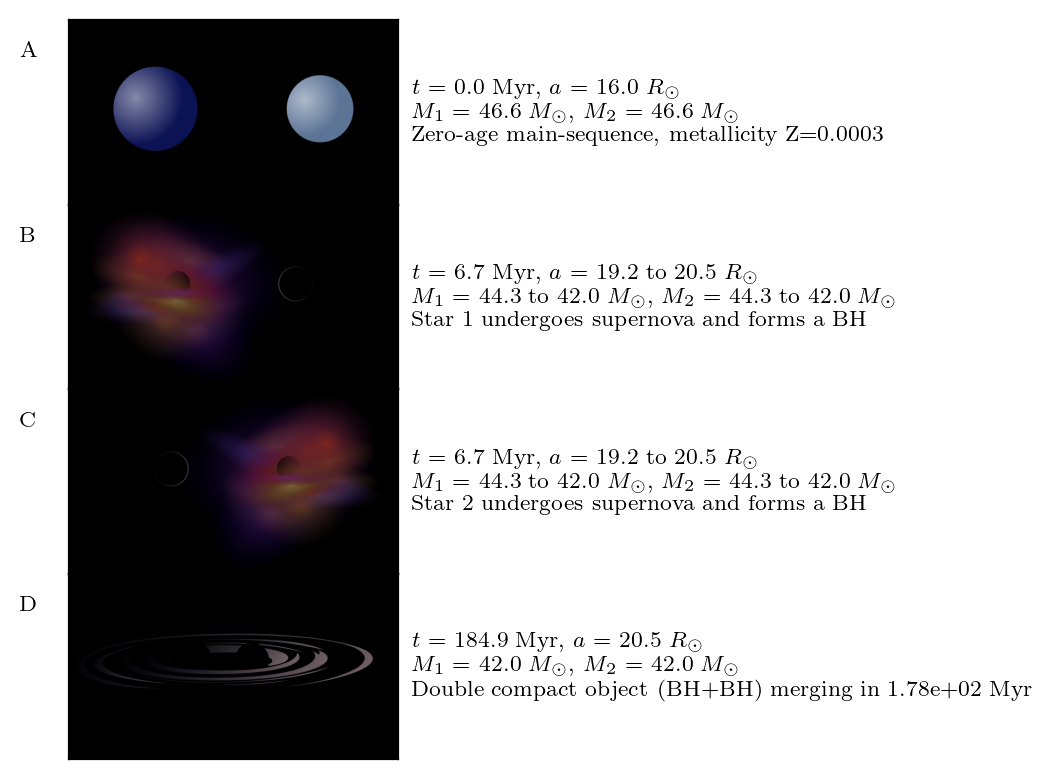

In [7]:
RawData = df_detailed_perfect
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_perfect['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [8]:
df_sanity_perfect = pd.read_csv(perfect_DataPath+'/sanity_checks.csv', header=0)
df_sanity_perfect = df_sanity_perfect.rename(columns=lambda x: x.strip())

df_sanity_perfect['SemiMajorAxis_Rsun'] = (df_sanity_perfect['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_perfect['Period1'] = (2 * np.pi / (df_sanity_perfect['Omega1'].values / u.yr)).to(u.day)
df_sanity_perfect['Period2'] = (2 * np.pi / (df_sanity_perfect['Omega2'].values / u.yr)).to(u.day)
df_sanity_perfect['Period_orb'] = (2 * np.pi / (df_sanity_perfect['Omega'].values / u.yr)).to(u.day)

df_sanity_perfect_short = df_sanity_perfect[columns_to_keep_sanity]

df_sanity_perfect

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn,SemiMajorAxis_Rsun,Period1,Period2,Period_orb
0,9976,0.000000,0.000064,16,16,413.221,413.221,385.359,385.359,13.93060,1.393060e+01,13.93060,1.393060e+01,2998.90,2998.90,2.998890e+03,2998.90,2.998890e+03,2998.90,0.000000,0,46.6202,6.787670,4.645240e-03,4.645240e-03,46.6202,6.787670,4.645240e-03,4.645240e-03,0.074247,0.074247,6.994450e-05,6.994450e-05,-6.994430e-05,-6.994430e-05,4.951580e-21,4.951580e-21,6.994470e-05,6.994470e-05,6.994450e-05,6.994450e-05,-6.994430e-05,-6.994430e-05,4.951580e-21,4.951580e-21,6.994470e-05,6.994470e-05,0,0,0,0,0,0,0,0,28.7038,3.890410,28.7038,3.890410,0,0,0,0,0,0,0,0,2.947940e+05,2.947940e+05,8.943740,8.943740,-4.593990e-20,-4.593990e-20,2.566480e-14,2.566480e-14,0,0,1.616180e+10,inf,1.168490e+09,1.168490e+09,-0.000009,-0.000009,0,0,0,0,0,0,0,0,0,0,7.181470e-06,7.181470e-06,-7.181450e-06,-7.181450e-06,5.083980e-22,5.083980e-22,7.181490e-06,7.181490e-06,-4.716830e-21,-4.716830e-21,-0.000000e+00,-0.000000e+00,2.635110e-15,2.635110e-15,15.965535,0.765258,0.765258,0.765258
1,9976,0.000064,0.063587,16,16,413.144,413.144,385.320,385.304,13.91220,1.392000e+01,13.91220,1.392000e+01,2996.85,2997.22,2.995530e+03,2997.22,2.995530e+03,2997.22,0.000000,0,46.6110,6.787670,4.644320e-03,4.644320e-03,46.6110,6.787670,4.644320e-03,4.644320e-03,0.074276,0.074270,6.974070e-05,6.974070e-05,-6.957720e-05,-6.957720e-05,4.957440e-13,4.957440e-13,6.990450e-05,6.990450e-05,6.974070e-05,6.974070e-05,-6.957720e-05,-6.957720e-05,4.957440e-13,4.957440e-13,6.990450e-05,6.990450e-05,0,0,0,0,0,0,0,0,28.6960,3.889780,28.6960,3.889780,0,0,0,0,0,0,0,0,2.946750e+05,2.946750e+05,8.942840,8.942840,-4.589160e-12,-4.589160e-12,2.563030e-06,2.563030e-06,0,0,1.618510e+02,inf,1.169260e+01,1.169260e+01,-0.009222,-0.009222,0,0,0,0,0,0,0,0,0,0,7.166290e-06,7.166290e-06,-7.149490e-06,-7.149490e-06,5.094080e-14,5.094080e-14,7.183120e-06,7.183120e-06,-4.715650e-13,-4.715650e-13,-0.000000e+00,-0.000000e+00,2.633670e-07,2.633670e-07,15.970460,0.765687,0.765687,0.765687
2,9976,0.063651,0.063597,16,16,413.067,413.067,385.264,385.249,13.90150,1.390940e+01,13.90150,1.390940e+01,2995.15,2995.52,2.993820e+03,2995.52,2.993820e+03,2995.52,0.000000,0,46.6016,6.787670,4.643390e-03,4.643390e-03,46.6016,6.787670,4.643390e-03,4.643390e-03,0.074299,0.074293,6.586430e-05,6.586430e-05,-6.570820e-05,-6.570820e-05,4.819220e-13,4.819220e-13,6.602070e-05,6.602070e-05,6.586430e-05,6.586430e-05,-6.570820e-05,-6.570820e-05,4.819220e-13,4.819220e-13,6.602070e-05,6.602070e-05,0,0,0,0,0,0,0,0,28.5735,3.863340,28.5735,3.863340,0,0,0,0,0,0,0,0,2.962680e+05,2.962680e+05,8.954900,8.954900,-4.453130e-12,-4.453130e-12,2.486420e-06,2.486420e-06,0,0

In [9]:
st_change_idx = np.where((df_sanity_perfect_short['StellarType_1'] != df_sanity_perfect_short['StellarType_1'].shift()) | (df_sanity_perfect_short['StellarType_2'] != df_sanity_perfect_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_perfect_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,46.6202,46.6202,6.787670,6.787670,0,28.7038,0,28.7038,0,3.890410,0,3.890410,15.965535,0,16,16,0.765258,0.765258,0.765258,1.393060e+01,1.393060e+01,385.359,0,0,4.951580e-21,4.951580e-21,4.951580e-21,4.951580e-21,0,0,0,0,5.083980e-22,5.083980e-22
102,6.44365,44.6728,44.6728,6.787670,6.787670,0,16.2579,0,16.2579,0,1.261570,0,1.261570,17.028762,0,16,16,0.861138,0.861138,0.861138,1.186240e+01,1.186240e+01,373.310,0,0,5.797000e-28,5.797000e-28,5.797000e-28,5.797000e-28,0,0,0,0,6.596670e-25,6.596670e-25
103,6.44365,44.6572,44.6572,2.327780,2.327780,0,44.6572,0,44.6572,0,2.327780,0,2.327780,19.041226,0,7,7,1.018395,1.018395,1.018395,1.179290e+00,1.179290e+00,394.546,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-9.257060e-05,-9.257060e-05
145,6.72292,44.2648,44.2648,2.315410,2.315410,0,36.4221,0,36.4221,0,0.000072,0,0.000072,19.218628,0,7,7,1.037230,1.037230,1.037230,1.135540e+00,1.135540e+00,391.166,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-1.137100e-14,-1.137100e-14
146,6.72292,42.0491,42.0491,0.000178,0.000178,0,42.0491,0,42.0491,0,0.000178,0,0.000178,20.493661,0,14,14,1.171847,1.171847,1.171847,2.264410e-08,2.264410e-08,373.989,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-2.030820e-03,-2.030820e-03


In [83]:
df_sn_perfect = pd.read_csv(perfect_DataPath+'/BSE_Supernovae.csv', skiprows=2, header=0)
df_sn_perfect = df_sn_perfect.rename(columns=lambda x: x.strip())
df_sn_perfect

,SEED,Drawn_Kick_Magnitude(SN),Applied_Kick_Magnitude(SN),Fallback_Fraction(SN),Orb_Velocity<SN,SN_Kick_Mean_Anomaly(SN),SN_Kick_Theta(SN),SN_Kick_Phi(SN),SN_Type(SN),Eccentricity<SN,Eccentricity,SemiMajorAxis<SN,SemiMajorAxis,Time,Supernova_State,Unbound,Stellar_Type(CP),Stellar_Type(SN),Stellar_Type_Prev(SN),Mass(CP),Mass_Total@CO(SN),Radius_Total@CO(SN),Mass_Core@CO(SN),Mass_CO_Core@CO(SN),Mass_He_Core@CO(SN),Radius_Core@CO(SN),Mass(SN),Experienced_RLOF(SN),MT_Donor_Hist(SN),ComponentSpeed(SN),ComponentSpeed(CP),SystemicSpeed,Is_Hydrogen_Poor(SN),SN_Orbit_Inclination_Angle,Orbital_AM_Vector>SN_X,Orbital_AM_Vector>SN_Y,Orbital_AM_Vector>SN_Z,SystemicVelocityX,SystemicVelocityY,SystemicVelocityZ,Ang_Momentum(SN),Ang_Momentum(CP),Record_Type
0,9976,0.0,0.0,0.0,925.392439,0.370348,0.410769,0.874859,8,0.000000,0.026346,19.219848,19.739909,6.722919,1,0,14,14,8,42.049135,44.264758,2.287533,36.422135,36.422135,44.264758,0.000071,42.049135,1,NA,11.877118,11.877118,11.877118,1,0.0,0.0,0.0,1.0,0.000000,-11.877118,0.0,1.13371,1.13371,1
1,9976,0.0,0.0,0.0,933.907570,5.750154,-0.781721,2.142855,8,0.026346,0.051302,19.739909,20.299334,6.722919,3,0,14,14,8,42.049135,44.264758,2.287533,36.422135,36.422135,44.264758,0.000071,42.049135,1,NA,22.623741,22.623741,22.623741,1,0.0,-0.0,0.0,1.0,-7.230331,-21.437256,0.0,1.13371,1.13371,1


In [120]:
pop_df = pd.read_csv('data_files/' + 'perfect_spin_df.csv') 
pop_df = pop_df.query('SEED == 9976')
pop_df

,SEED,Mass@ZAMS(1),Mass@ZAMS(2),Metallicity@ZAMS(1),Omega(1),Omega(2),Eccentricity@ZAMS,SemiMajorAxis@ZAMS,CH_on_MS(1),CH_on_MS(2),Mass@DCO(1),Mass@DCO(2),SemiMajorAxis@DCO,Eccentricity@DCO,Stellar_Type(1),Stellar_Type(2),Merges_Hubble_Time,Time@DCO,Coalescence_Time,M_min@DCO,M_max@DCO,Ang_Momentum(SN)_Primary,Ang_Momentum(SN)_Secondary,Ang_Momentum(SN)_Both,MT_Donor_Hist(SN)_Primary,MT_Donor_Hist(SN)_Secondary,Mass(CP)_Primary,Mass(CP)_Secondary,Mass(CP)_Both,Mass(SN)_Primary,Mass(SN)_Secondary,Mass(SN)_Both,Mass_CO_Core@CO(SN)_Primary,Mass_CO_Core@CO(SN)_Secondary,Mass_CO_Core@CO(SN)_Both,Mass_Core@CO(SN)_Primary,Mass_Core@CO(SN)_Secondary,Mass_Core@CO(SN)_Both,Mass_Total@CO(SN)_Primary,Mass_Total@CO(SN)_Secondary,Mass_Total@CO(SN)_Both,Number_of_RLOF(SN)_Primary,Number_of_RLOF(SN)_Secondary,Number_of_RLOF(SN)_Both,Omega(SN)_Primary,Omega(SN)_Secondary,Omega(SN)_Both,Orbital_Period<SN_Primary,Orbital_Period<SN_Secondary,Orbital_Period<SN_Both,RLOF_Primary,RLOF_Secondary,RLOF_Both,Radius_Core@CO(SN)_Primary,Radius_Core@CO(SN)_Secondary,Radius_Core@CO(SN)_Both,Radius_Total@CO(SN)_Primary,Radius_Total@CO(SN)_Secondary,Radius_Total@CO(SN)_Both,SN_Orbit_Inclination_Angle_Primary,SN_Orbit_Inclination_Angle_Secondary,SN_Orbit_Inclination_Angle_Both,SN_Type(SN)_Primary,SN_Type(SN)_Secondary,SN_Type(SN)_Both,SemiMajorAxis<SN_Primary,SemiMajorAxis<SN_Secondary,SemiMajorAxis<SN_Both,Stellar_Type_Prev(SN)_Primary,Stellar_Type_Prev(SN)_Secondary,Stellar_Type_Prev(SN)_Both,Time@SN_Primary,Time@SN_Secondary,Time@SN_Both,Eccentricity<CE_Primary,Eccentricity<CE_Secondary,Eccentricity<CE_Both,Mass(1)<CE_Primary,Mass(1)<CE_Secondary,Mass(1)<CE_Both,Mass(2)<CE_Primary,Mass(2)<CE_Secondary,Mass(2)<CE_Both,SemiMajorAxis<CE_Primary,SemiMajorAxis<CE_Secondary,SemiMajorAxis<CE_Both,Stellar_Type(1)<CE_Primary,Stellar_Type(1)<CE_Secondary,Stellar_Type(1)<CE_Both,Stellar_Type(1)>CE_Primary,Stellar_Type(1)>CE_Secondary,Stellar_Type(1)>CE_Both,Stellar_Type(2)<CE_Primary,Stellar_Type(2)<CE_Secondary,Stellar_Type(2)<CE_Both,Stellar_Type(2)>CE_Primary,Stellar_Type(2)>CE_Secondary,Stellar_Type(2)>CE_Both,Time@CE_Primary,Time@CE_Secondary,Time@CE_Both,CE_Primary,CE_Secondary,CE_Both,BBH,BHNS,BNS,z_form,z_merger,a1,a2,a1_orb,a2_orb,fallback_1,fallback_2,iota1,iota2,chi_eff,chi_eff_orb
9359,9976,46.620192,46.620192,0.000312,0.000062,0.000062,0.0,0.074247,True,True,42.049135,42.049135,0.095305,0.0,14,14,True,6.722919,178.38747,42.049135,42.049135,1.13371,NaN,1.13371,NaN,NaN,42.049135,NaN,42.049135,42.049135,NaN,42.049135,36.422135,NaN,36.422135,36.422135,NaN,36.422135,44.264758,NaN,44.264758,0.0,NaN,0.0,3107.003666,NaN,3107.003666,1.050577,NaN,1.093505,True,True,True,0.000071,NaN,0.000071,2.287533,NaN,2.287533,0.0,NaN,0.0,8.0,NaN,8.0,0.089381,NaN,0.0918,8.0,NaN,8.0,6.722919,NaN,6.722919,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,True,False,False,8.910069,7.172876,0.674162,0.674162,0.126034,0.121087,0.71749,0.71749,0.0,0.0,0.674162,0.12356


In [121]:
m2 = pop_df["Mass_Total@CO(SN)_Both"].values * u.M_sun
r2 = pop_df["Radius_Total@CO(SN)_Both"].values * u.R_sun
m2_remnant = pop_df["Mass@DCO(2)"].values * u.M_sun
m2_core = pop_df["Mass_CO_Core@CO(SN)_Both"].values * u.M_sun
r2_core = pop_df["Radius_Core@CO(SN)_Both"].values * u.R_sun
period_orb2 = pop_df["Orbital_Period<SN_Both"].values * u.d
st2 = pop_df['Stellar_Type_Prev(SN)_Both']
omega_orb_2 = (2 * np.pi / period_orb2).to(1/u.yr)

j2 = pop_df['Ang_Momentum(SN)_Both'].values * u.Msun * u.AU**2 / u.yr
m2_shell = m2 - m2_core
# I2 = (0.21 * m2_core * (r2_core**2) + 0.1 * m2_shell * (r2**2))
# I2 = (0.1 * (m2) * (r2) * (r2))
I2 = 0.1 * m2 * r2**2
gb_mask = (st2==8)
I2[gb_mask] = (0.21 * m2_core * (r2_core**2) + 0.1 * m2_shell * (r2**2))

omega2 = (j2 / I2).to(1/u.yr)   


(2*np.pi/omega2).to(u.d), (2*np.pi/omega_orb_2).to(u.d)


(<Quantity [0.17966256] d>, <Quantity [1.09350475] d>)

In [122]:
m2_core, m2_shell

(<Quantity [36.42213514] solMass>, <Quantity [7.84262298] solMass>)

In [114]:
a = (c.c * (j_core + (1*j_shell))/ (c.G * (m2_remnant)**2)).to(u.dimensionless_unscaled)
a

<Quantity [0.16876472]>

In [111]:
(0.21 * m2_core * (r2_core**2) + 0.1 * m2_shell * (r2**2))

<Quantity [4.10389395] solRad2 solMass>

In [109]:
omega2.to(1/u.d), omega_orb_2.to(1/u.d)

(<Quantity [34.97214689] 1 / d>, <Quantity [5.74591497] 1 / d>)

In [105]:
j_core = 0.21 * m2_core * (r2_core**2) * omega2
j_shell = 0.1 * m2_shell * (r2**2) * omega2

# print((j_core + j_shell).to(u.Msun * u.AU**2 / u.yr))

print((I2 * omega2).to(u.Msun * u.AU**2 / u.yr))

fallback_fraction = np.maximum((m2_remnant - m2_core)/m2_shell, 0)
fallback_fraction = np.nan_to_num(fallback_fraction, nan=0.0, posinf=0.0, neginf=0.0) # For stars with no shell, fallback fraction becomes NaN or inf. If so, ignore the shell angular momentum.
fallback_fraction = np.minimum(fallback_fraction, 1.0) # Cap fallback fraction at 1.0

a = (c.c * (j_core + (fallback_fraction*j_shell))/ (c.G * (m2_remnant)**2)).to(u.dimensionless_unscaled)

a

[1.13370962] AU2 solMass / yr


<Quantity [0.73698596]>

In [106]:
j_core = 0.21 * m2_core * (r2_core**2) * (2 * np.pi / period_orb2).to(1/u.yr)
j_shell = 0.1 * m2_shell * (r2**2) * (2 * np.pi / period_orb2).to(1/u.yr)

print((j_core + j_shell).to(u.Msun * u.AU**2 / u.yr))


fallback_fraction = np.maximum((m2_remnant - m2_core)/m2_shell, 0)
fallback_fraction = np.nan_to_num(fallback_fraction, nan=0.0, posinf=0.0, neginf=0.0) # For stars with no shell, fallback fraction becomes NaN or inf. If so, ignore the shell angular momentum.
fallback_fraction = np.minimum(fallback_fraction, 1.0) # Cap fallback fraction at 1.0

a = (c.c * (j_core + (fallback_fraction*j_shell))/ (c.G * (m2_remnant)**2)).to(u.dimensionless_unscaled)
a

[0.18626821] AU2 solMass / yr


<Quantity [0.12108661]>